# CF v4 — FastDiME against the final_experiment C0

 `FastDiME_Med` ships the authors' own code.
v3 paraphrased it and diverged in eight places:

| | v3 (from the paper) | `CFgenerating/config_cf.py` |
|---|---|---|
| schedule | 400 respaced from 1000 | 1000, `rescale_t = False` — no respacing |
| τ (`cf_from_timestep`) | 160 | **400** |
| mask warm-up | τ/2 = 80, relative | `start_tau = 200`, an absolute timestep |
| gradient scale | *absent* | `start_scale = 100` |
| distance loss | L1 weight 50 | `Denoised_L1` weight **200** (50 is the *DiME* setting) |
| mean update | μ − Σ·∇ | μ − β_t·∇·scale/√α_t |
| sample std | √β̃ (posterior) | √β_t |
| background re-anchor | `q_sample(x₀, t−1)` | `q_sample(x₀, t)` |
| returned CF | x_{t−1} | the last denoised **x̄₀** |


**The one deviation that cannot be removed.** Their classifier is a timestep-conditioned UNet
encoder (`ts_guided = True`), so they use `GuidedDiffusionTS`. Ours is a plain DenseNet with no
timestep input, so we use the base `GuidedDiffusion`. The *loss* is unaffected: with
`grad_obt_from='denoised_img'`, `GuidedDiffusionTS.get_guided_gradient` clones the same denoised
tensor twice and sums both gradients, so their `['Lc','Denoised_L1','L1'] @ [1, 200, 0]` is
arithmetically identical to the base class's `['Lc','L1'] @ [1, 200]`.

Reference numbers (their CheXpert pacemaker-removal row): **L1 0.0897, MAD 0.7554, FID 61.40**.

## 1. Setup

In [ ]:
import os, sys
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

sys.path.insert(0, "/zhome/d0/a/221493/thesis/final_experiment/code")
import cf_generation_final as cf

DISEASE = os.environ.get("THESIS_TASK", "effusion")  # default to cardiomegaly if not set

# load_models resolves everything from the disease: the 14-logit multilabel
# checkpoint, which logit to guide on, and that disease's operating threshold.
unet, classifier, seg_model, cfg = cf.load_models(DISEASE)
seg_model = seg_model.to(cf.DEVICE)

print(f"\ndevice    {cf.DEVICE}  | torch {torch.__version__}")
print(f"C0        {cfg.model_path}")
print(f"logit     {cfg.target_idx} ({cfg.target_col}) of {len(cfg.labels)}")
print(f"C2 data   {cfg.c2_csv}")
print(f"threshold {cfg.threshold:.4f}  (Youden's J, from {cfg.threshold_file})")

TaskConfig(disease='cardiomegaly', target_col='Cardiomegaly', logit 2/14, threshold=0.1598 from threshold.txt)
UNet loaded (24.0M params)
Segmentation model loaded (14 classes)
C0 loaded: 14-logit multilabel, guiding on 'Cardiomegaly' (index 2) | threshold 0.1598

device    cuda  | torch 2.0.1+cu117
C0        /work3/s251710/thesis_results/C0_final/multilabel_ignore/c0_best.pt
logit     2 (Cardiomegaly) of 14
C2 data   /work3/s251710/thesis_results/C2_final/cardiomegaly/c2_data.csv
threshold 0.1598  (Youden's J, from threshold.txt)


## 2. Hyperparameters

All of these come from `CFgenerating/config_cf.py`; none are retyped here.

In [ ]:
print(f"total_timesteps  {cf.TOTAL_TIMESTEPS}   (matches the diffusion checkpoint)")
print(f"cf_from_timestep {cf.CF_FROM_TIMESTEP}   (tau: where the reverse process starts)")
print(f"start_tau        {cf.START_TAU}   (inpainting engages once timestep <= this)")
print(f"dilation         {cf.DILATION}")
print(f"inpaint_th       {cf.INPAINT_TH}")
print(f"start_scale      {cf.START_SCALE}   (gradient scale — absent from v3)")
print(f"weights          Lc={cf.W_LC}, Denoised_L1={cf.W_DENOISED_L1}")

print("\nmodes:")
for name, preset in cf.FASTDIME_PRESETS.items():
    print(f"  {name:14s} grad_obt_from={preset['grad_obt_from']:15s} "
          f"weights={preset['grad_loss_weights']}  inpaint={preset['inpaint_type']}")

# Cost: one UNet call per step. Their loop is `reversed(range(1, 400))`,
# so t runs 399..1 and t = 0 is never visited.
print(f"\n{cf.CF_FROM_TIMESTEP - 1} UNet calls per counterfactual")



total_timesteps  1000   (matches the diffusion checkpoint)
cf_from_timestep 50   (tau: where the reverse process starts)
start_tau        25   (inpainting engages once timestep <= this)
dilation         21
inpaint_th       0.15
start_scale      100   (gradient scale — absent from v3)
weights          Lc=1.0, Denoised_L1=10

modes:
  FastDiME       grad_obt_from=denoised_img    weights=[1.0, 10]  inpaint=dynamic
  FastDiME-woM   grad_obt_from=denoised_img    weights=[1.0, 10]  inpaint=None
  DiME           grad_obt_from=generated_img   weights=[1.0, 50.0]  inpaint=None
  noise floor    grad_obt_from=denoised_img    weights=[0.0, 0.0]  inpaint=None

49 UNet calls per counterfactual


In [ ]:
df = pd.read_csv(cfg.c2_csv)

## 3. Choose the working sample

**Everything below uses this one image.** Change `CELL` / `PICK` here and re-run the
notebook top to bottom — no other section picks its own image.

| | |
|---|---|
| `CELL` | which confusion cell: `"TP"`, `"TN"`, `"FP"`, `"FN"` |
| `PICK` | which image from that cell (any integer; changes the draw) |
| `MARGIN` | require `\|prob − threshold\|` > this, to avoid borderline cases |
| `SAMPLER_SEED` | the diffusion noise draw — *not* the image choice |

In [ ]:
# ══ THE working sample. Everything downstream reads `row` / `x0` from here. ══
CELL         = "TN"    # "TP" | "TN" | "FP" | "FN"
PICK         = 3       # which image from that cell
MARGIN       = 0.0     # require |prob - threshold| > MARGIN
SAMPLER_SEED = 0       # diffusion noise draw (NOT the image choice)

_masks = {"TP": (df.pred == 1) & (df.true == 1),
          "TN": (df.pred == 0) & (df.true == 0),
          "FP": (df.pred == 1) & (df.true == 0),
          "FN": (df.pred == 0) & (df.true == 1)}

pool = df[_masks[CELL] & ((df.prob - cfg.threshold).abs() > MARGIN)]
row  = pool.sample(1, random_state=PICK).iloc[0]

x0        = cf.load_image(row["path"])
p_orig    = cf.get_c0_prob(x0, classifier)
pred_orig = cf.predict(p_orig, cfg)
target    = 1 - pred_orig                                    # §3 uses this
direction = "to_positive" if pred_orig == 0 else "to_negative"   # §6 uses this

print(f"CELL={CELL}  PICK={PICK}   pool={len(pool):,} images")
print(f"path      {row['path']}")
print(f"C0 prob   {p_orig:.4f}   threshold {cfg.threshold:.4f}   pred={pred_orig}")
print(f"direction {direction}   (flip target = {target})")

CELL=TN  PICK=3   pool=66,178 images
path      CheXpert-v1.0-small/train/patient02377/study6/view1_frontal.jpg
C0 prob   0.0066   threshold 0.1598   pred=0
direction to_positive   (flip target = 1)


## 4. One image, three modes

`DiME` is deliberately left out of the sweep: it takes the gradient on a *fully generated*
image, which means an inner reverse loop at every step — O(T²). Run it on a single image if
you want it, never over a set.

The counterfactual returned is the final denoised estimate x̄₀ at t=1, which is what their
`one_CF_procedure` treats as the CF (`records[0][-1]`).

### 4.1 The working sample

Set in §3. Re-run that cell to change it; this one only reports what was chosen.

TN  thr=0.160  p=0.0066  target=1
path  CheXpert-v1.0-small/train/patient02377/study6/view1_frontal.jpg


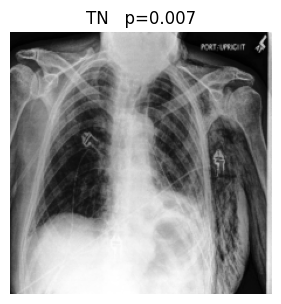

In [ ]:
# row / x0 / p_orig / pred_orig / target all come from §3.
print(f"{CELL}  thr={cfg.threshold:.3f}  p={p_orig:.4f}  target={target}")
print(f"path  {row['path']}")

plt.figure(figsize=(3.4, 3.4))
plt.imshow(cf.to_np(x0), cmap="gray", vmin=0, vmax=1)
plt.title(f"{CELL}   p={p_orig:.3f}"); plt.axis("off"); plt.show()

### 4.2 Threshold sanity check

Confirms `cfg.threshold` is the number that actually produced `pred` in `c2_data.csv`.
If `pred == (prob > thr)` is not ~100%, the counting of flips downstream is off.

In [ ]:
agree      = ((df.prob > cfg.threshold).astype(int) == df.pred).mean()
implied_lo = df.loc[df.pred == 1, "prob"].min()   # lowest prob still called positive
implied_hi = df.loc[df.pred == 0, "prob"].max()   # highest prob still called negative
print(f"cfg.threshold          = {cfg.threshold:.4f}")
print(f"pred == (prob>thr) for   {agree:.1%} of rows")
print(f"min prob among pred==1 = {implied_lo:.4f}")
print(f"max prob among pred==0 = {implied_hi:.4f}")

cfg.threshold          = 0.1598
pred == (prob>thr) for   100.0% of rows
min prob among pred==1 = 0.1598
max prob among pred==0 = 0.1598


### 4.3 The three modes, side by side

`FastDiME` (masked), `FastDiME-woM` (unmasked) and `noise floor` (guidance off) on the
same image. The floor is the control: whatever it changes is the sampler's own churn, not
an edit the classifier asked for.

FastDiME t=50:   0%|          | 0/49 [00:00<?, ?it/s]

FastDiME-woM t=50:   0%|          | 0/49 [00:00<?, ?it/s]

noise floor t=50:   0%|          | 0/49 [00:00<?, ?it/s]

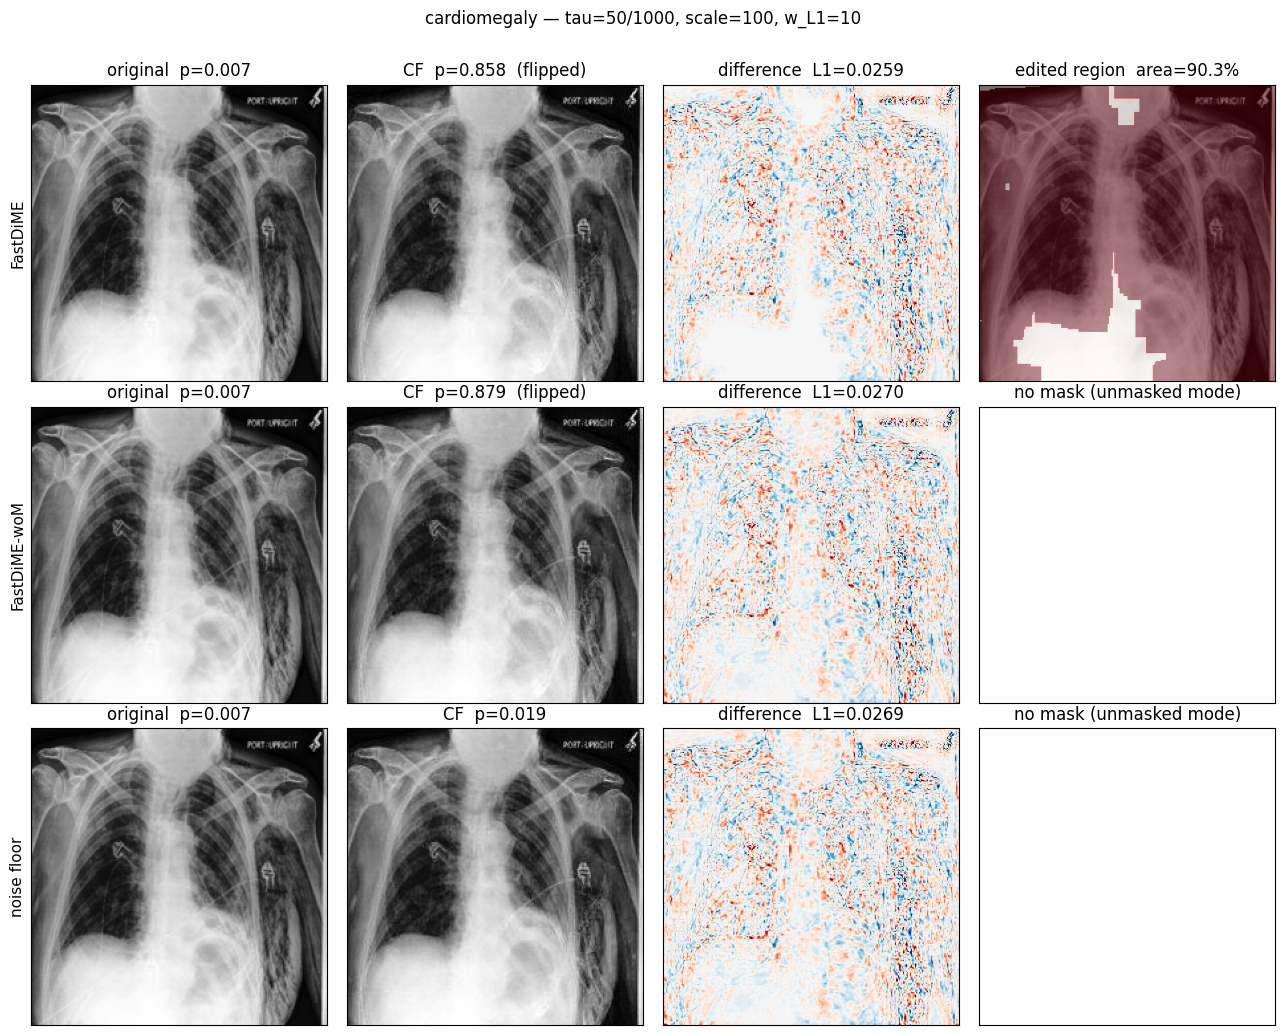

original          0.007
noise floor       0.019   drift = +0.013
FastDiME          0.858   lift over floor = +0.838
FastDiME-woM      0.879   lift over floor = +0.859


In [ ]:
MODES = ["FastDiME", "FastDiME-woM", "noise floor"]

fig, axes = plt.subplots(len(MODES), 4, figsize=(13, 3.4 * len(MODES)))
probs = {}

for r, name in enumerate(MODES):

    
    x_cf, cf_prob, boolmask, traj = cf.generate_cf(
        x0, target, unet, classifier, mode=name, cf_from_timestep = 50, track_every=20)
    probs[name] = cf_prob
    
    diff = cf.to_np(x_cf) - cf.to_np(x0)
    vmax = 0.15
    flipped = cf.predict(cf_prob, cfg) != pred_orig

    axes[r, 0].imshow(cf.to_np(x0), cmap="gray")
    axes[r, 0].set_ylabel(name, fontsize=11)
    axes[r, 0].set_title(f"original  p={p_orig:.3f}")
    axes[r, 1].imshow(cf.to_np(x_cf), cmap="gray")
    axes[r, 1].set_title(f"CF  p={cf_prob:.3f}" + ("  (flipped)" if flipped else ""))
    axes[r, 2].imshow(diff, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[r, 2].set_title(f"difference  L1={cf.l1(x0, x_cf):.4f}")

    if boolmask is None:
        axes[r, 3].imshow(np.ones((224, 224)), cmap="gray", vmin=0, vmax=1)
        axes[r, 3].set_title("no mask (unmasked mode)")
    else:
        # their boolmask marks the BACKGROUND to restore; the edited region is
        # its complement, which is what cf.edited_mask returns
        em = cf.edited_mask(x0, x_cf)[0, 0].cpu().numpy()
        axes[r, 3].imshow(cf.to_np(x0), cmap="gray")
        axes[r, 3].imshow(em, cmap="Reds", alpha=0.45)
        axes[r, 3].set_title(f"edited region  area={em.mean():.1%}")

    for c in range(4):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

plt.suptitle(f"{DISEASE} — tau={cf.CF_FROM_TIMESTEP}/{cf.TOTAL_TIMESTEPS}, "
             f"scale={cf.START_SCALE}, w_L1={cf.W_DENOISED_L1}", y=1.01)
plt.tight_layout(); plt.show()

s = 1 if target == 1 else -1
print(f"original          {p_orig:.3f}")
print(f"noise floor       {probs['noise floor']:.3f}   "
      f"drift = {s*(probs['noise floor'] - p_orig):+.3f}")
for m in ("FastDiME", "FastDiME-woM"):
    print(f"{m:18s}{probs[m]:.3f}   "
          f"lift over floor = {s*(probs[m] - probs['noise floor']):+.3f}")

### 4.4 Isolating the edit

Guided minus unguided at the same seed cancels the churn, leaving the part attributable
to the classifier. `MULTIPLY` amplifies it for display only.

In [ ]:
tau = 50
seed = 0

MULTIPLY = 3

In [ ]:
xg, pg, _, _ = cf.generate_cf(x0, target, unet, classifier, mode="FastDiME-woM",
                                  cf_from_timestep=tau, seed=seed, progress=False)
xf, pf, _, _ = cf.generate_cf(x0, target, unet, classifier, mode="noise floor",
                                  cf_from_timestep=tau, seed=seed, progress=False)
edit     = cf.to_np(xg) - cf.to_np(xf)               # churn cancels -> guidance edit
cf_clean = np.clip(cf.to_np(x0) + MULTIPLY*edit, 0, 1)        # original + edit, no churn



KeyboardInterrupt: 

In [ ]:
def np01_to_tensor(a):
    t = torch.from_numpy(a).float().unsqueeze(0).unsqueeze(0)
    return (t * 2 - 1).to(cf.DEVICE)

x_clean = np01_to_tensor(cf_clean)
p_clean = cf.get_c0_prob(x_clean, classifier)
print(f"original      p={p_orig:.3f}")
print(f"guided CF     p={pg:.3f}")
print(f"clean CF      p={p_clean:.3f}")   # x0 + (guided - floor)

original      p=0.772
guided CF     p=0.107
clean CF      p=0.080


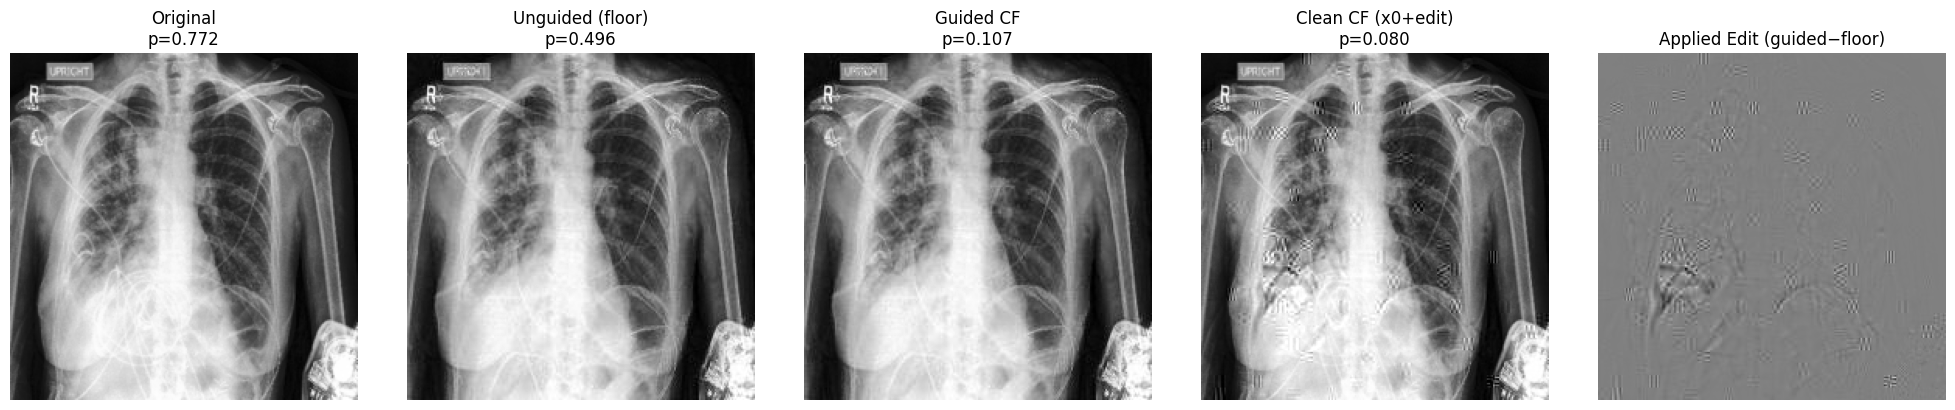

In [ ]:


ev = np.abs(edit).max()
panels = [
    (cf.to_np(x0), f"Original\np={p_orig:.3f}",              dict(cmap='gray', vmin=0, vmax=1)),
    (cf.to_np(xf), f"Unguided (floor)\np={pf:.3f}",          dict(cmap='gray', vmin=0, vmax=1)),
    (cf.to_np(xg), f"Guided CF\np={pg:.3f}",                 dict(cmap='gray', vmin=0, vmax=1)),
    (cf_clean,     f"Clean CF (x0+edit)\np={p_clean:.3f}",   dict(cmap='gray', vmin=0, vmax=1)),
    (edit,         "Applied Edit (guided−floor)",            dict(cmap='gray', vmin=-ev, vmax=ev)),
]

plt.figure(figsize=(20, 4))
for i, (img, title, kw) in enumerate(panels, 1):
    plt.subplot(1, 5, i)
    plt.imshow(img, **kw); plt.title(title); plt.axis('off')
plt.tight_layout(); plt.show()

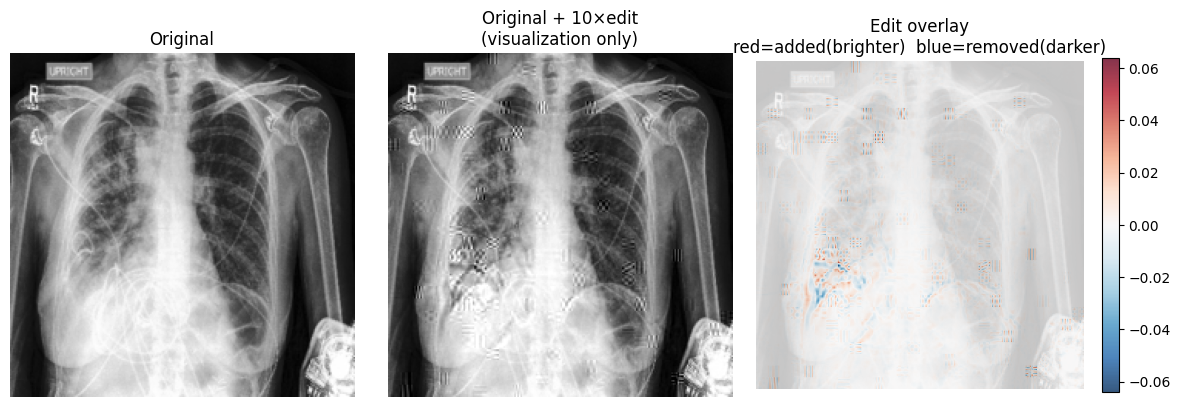

In [ ]:
MULTIPLY = 10
cf_amplified = np.clip(cf.to_np(x0) + MULTIPLY * edit, 0, 1)

ev = np.abs(edit).max()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(cf.to_np(x0), cmap='gray')
ax[0].set_title('Original'); ax[0].axis('off')

ax[1].imshow(cf_amplified, cmap='gray')
ax[1].set_title(f'Original + {MULTIPLY}×edit\n(visualization only)'); ax[1].axis('off')

ax[2].imshow(cf.to_np(x0), cmap='gray')
im = ax[2].imshow(edit, cmap='RdBu_r', vmin=-ev, vmax=ev, alpha=0.8)
ax[2].set_title('Edit overlay\nred=added(brighter)  blue=removed(darker)')
ax[2].axis('off')
plt.colorbar(im, ax=ax[2], fraction=0.046)

plt.tight_layout(); plt.show()

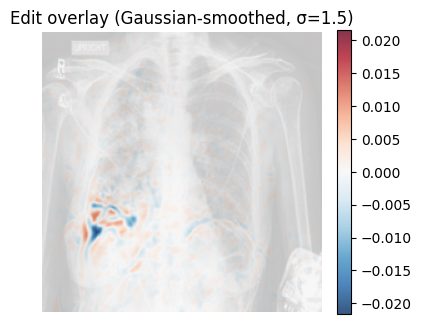

In [ ]:
cfrom scipy.ndimage import gaussian_filter
edit_smooth = gaussian_filter(edit, sigma=1.5)

ev = np.abs(edit_smooth).max()
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(cf.to_np(x0), cmap='gray')
im = ax.imshow(edit_smooth, cmap='RdBu_r', vmin=-ev, vmax=ev, alpha=0.8)
ax.set_title('Edit overlay (Gaussian-smoothed, σ=1.5)')
ax.axis('off'); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

### 4.5 Where the edit lands

Segment the original and ask what fraction of the edit falls in each anatomical region.
`ratio` > 1 means the edit is concentrated there relative to that region's area.

In [ ]:
# ── where does the edit land? ─────────────────────────────────────────────────
REGIONS = ["Heart", "Left Lung", "Right Lung", "Facies Diaphragmatica", "Spine"]

seg = cf.segment_image(x0, seg_model.cpu()); seg_model = seg_model.to(cf.DEVICE)

for name in ("FastDiME", "FastDiME-woM","noise floor"):
    x_cf, p, _, _ = cf.generate_cf(x0, target, unet, classifier,
                                   mode=name, progress=False)
    d = np.abs(cf.to_np(x_cf) - cf.to_np(x0))          # magnitude of the edit
    print(f"\n{name}   p={p:.3f}   L1={d.mean():.4f}")
    print(f"  {'region':24s} {'% of edit':>10} {'% of image':>11} {'ratio':>7}")
    for reg in REGIONS:
        rm = seg[seg_model.targets.index(reg)].astype(bool)
        share = d[rm].sum() / max(d.sum(), 1e-8)        # fraction of total edit here
        area  = rm.mean()                               # fraction of the image
        print(f"  {reg:24s} {share:9.1%} {area:10.1%} {share/max(area,1e-8):7.2f}")


FastDiME   p=0.100   L1=0.0283
  region                    % of edit  % of image   ratio
  Heart                         4.0%       5.1%    0.79
  Left Lung                    15.7%      13.8%    1.14
  Right Lung                   16.4%      13.4%    1.23
  Facies Diaphragmatica        14.1%      17.0%    0.83
  Spine                         7.1%       9.3%    0.76

FastDiME-woM   p=0.107   L1=0.0284
  region                    % of edit  % of image   ratio
  Heart                         4.0%       5.1%    0.78
  Left Lung                    15.3%      13.8%    1.11
  Right Lung                   16.3%      13.4%    1.22
  Facies Diaphragmatica        14.3%      17.0%    0.84
  Spine                         7.2%       9.3%    0.78

noise floor   p=0.496   L1=0.0285
  region                    % of edit  % of image   ratio
  Heart                         4.0%       5.1%    0.78
  Left Lung                    15.4%      13.8%    1.11
  Right Lung                   16.2%      13.4%    

## 5. Is the distance term doing anything?

v3 raised this because it paired weight 50 with a `.mean()` reduction and suspected the L1
gradient was inert. The reference answers it: the weight is **200**, and their `get_l1_loss`
does use a mean (`nn.L1Loss(reduction='none')`, then `.view(BS,-1).mean(1)`). So the mean was
right and the weight was the thing v3 had wrong.

Worth printing anyway — it is the ratio, not either norm alone, that says whether the distance
term can restrain the classifier term.

In [ ]:
import torch.nn.functional as F

sd = cf.make_sampler("FastDiME")
t_probe = cf.CF_FROM_TIMESTEP // 2
t = torch.full((1,), t_probe, dtype=torch.long, device=cf.DEVICE)

x_t, _ = sd.forward_diffusion(
    x0, torch.as_tensor(t_probe, dtype=torch.long, device=cf.DEVICE))
out = sd.p_mean_std(model=unet, x_t=x_t, t=t)
x_denoised = out["denoised"].detach()

y = torch.full((1, 1), float(target), device=cf.DEVICE)

# exactly the two loss terms their get_guided_gradient assembles
for label, fn in [
    (f"Lc            (w={cf.W_LC})",
     lambda v: cf.W_LC * F.binary_cross_entropy(torch.sigmoid(classifier(v)), y)),
    (f"Denoised_L1   (w={cf.W_DENOISED_L1})",
     lambda v: cf.W_DENOISED_L1 * (v - x0).abs().view(1, -1).mean(1)),
]:
    v = x_denoised.clone().requires_grad_(True)
    g = torch.autograd.grad(fn(v).mean(), v)[0]
    print(f"{label:28s} grad norm {g.norm().item():.6g}")

Lc            (w=1.0)        grad norm 7.43085
Denoised_L1   (w=10)         grad norm 0.0446429


## 6. Protocol metrics over a set

Their protocol: L1 and FID for closeness and realism, MAD for validity. Flip rate uses this
disease's Youden's-J threshold — the same number that produced `pred` in `c2_data.csv`, so a
"flip" here means what it means in C2.

**Cost.** 399 UNet calls per CF per mode. At N=20 and three modes that is ~24k UNet calls.
Start small; raise to 250 only for FID, and only on GPU.

In [ ]:
N_PER_CELL = 5            # 5 each of TP, TN, FP, FN -> 20 images
MODES = ["FastDiME", "FastDiME-woM", "noise floor"]
WITH_FID   = False        # needs >= ~200 flipped CFs per mode to mean anything

cells = {"TN": (0, 1), "FN": (0, 0), "TP": (1, 1), "FP": (1, 0)}   # (pred, correct)
parts = []
for cell, (p, c) in cells.items():
    pool = df[(df["pred"] == p) & (df["correct"] == c)]
    take = min(N_PER_CELL, len(pool))
    if take < N_PER_CELL:
        print(f"[warn] {cell} has only {len(pool)} rows")
    parts.append(pool.sample(take, random_state=1).assign(cell=cell))
sub = pd.concat(parts).reset_index(drop=True)
print(sub["cell"].value_counts().to_string(), "\n")

samplers = {m: cf.make_sampler(m) for m in MODES}
records, store = [], {m: {"orig": [], "cf": []} for m in MODES}

for img_id, (_, r) in enumerate(tqdm(list(sub.iterrows()), desc="images")):
    xi = cf.load_image(r["path"])
    p_i = cf.get_c0_prob(xi, classifier)
    pred_i = cf.predict(p_i, cfg)
    tgt = 1 - pred_i

    for name in MODES:
        x_cf, cf_prob, boolmask, _ = cf.generate_cf(
            xi, tgt, unet, classifier, sd=samplers[name], progress=False)
        flipped = cf.predict(cf_prob, cfg) != pred_i
        area = (np.nan if boolmask is None
                else float(cf.edited_mask(xi, x_cf).mean()))
        records.append({
            "img": img_id, "cell": r["cell"], "mode": name,
            "correct": int(r["correct"]), "target": tgt,
            "orig_prob": p_i, "cf_prob": cf_prob,
            "l1": cf.l1(xi, x_cf), "flipped": int(flipped), "edited_area": area,
        })
        if flipped:
            store[name]["orig"].append(xi.cpu()); store[name]["cf"].append(x_cf.cpu())

res = pd.DataFrame(records)

summary = res.groupby("mode").apply(lambda g: pd.Series({
    "L1":  g.l1.mean(),
    "MAD": cf.mad(g.orig_prob, g.cf_prob),
    "FR":  g.flipped.mean(),
    "edited_area": g.edited_area.mean(),
}),)

if WITH_FID:
    summary["FID"] = [cf.compute_fid(store[m]["orig"], store[m]["cf"])
                      if len(store[m]["cf"]) >= 200 else np.nan for m in summary.index]

print(summary.round(4).to_string())
print(f"\nFastDiME CheXpert reference: L1={cf.FASTDIME_REF['l1']}  "
      f"MAD={cf.FASTDIME_REF['mad']}  FID={cf.FASTDIME_REF['fid']}")


cell
TN    5
FN    5
TP    5
FP    5 



images:   0%|          | 0/20 [00:00<?, ?it/s]

### 6.1 Save the raw records

`cf_eval_store.pt` keeps the flipped original/CF tensors, which FID needs.

In [ ]:
import pickle, torch
res = pd.DataFrame(records)
res.to_csv("cf_eval_records.csv", index=False)
torch.save(store, "cf_eval_store.pt")   # flipped orig/cf tensors, needed for FID
DISEASE = "cardiomegaly"


### 6.2 Summary table

In [ ]:
summary = pd.DataFrame({
    m: {
        "L1": g.l1.mean(),
        "MAD": cf.mad(g.orig_prob, g.cf_prob),
        "FR": g.flipped.mean(),
        "edited_area": g.edited_area.mean(),
    }
    for m, g in res.groupby("mode")
}).T

if WITH_FID:
    summary["FID"] = [cf.compute_fid(store[m]["orig"], store[m]["cf"])
                      if len(store[m]["cf"]) >= 200 else np.nan for m in summary.index]

print(summary.round(4).to_string())
print(f"\nFastDiME CheXpert reference: L1={cf.FASTDIME_REF['l1']}  "
      f"MAD={cf.FASTDIME_REF['mad']}  FID={cf.FASTDIME_REF['fid']}")

                  L1     MAD   FR  edited_area
FastDiME      0.0224  0.6544  1.0        0.901
FastDiME-woM  0.0237  0.6559  1.0          NaN
noise floor   0.0237  0.1732  0.2          NaN

FastDiME CheXpert reference: L1=0.0897  MAD=0.7554  FID=61.4


### 6.3 Summary chart

Text(0.5, 1.0, 'Counterfactual Evaluation Summary (cardiomegaly)')

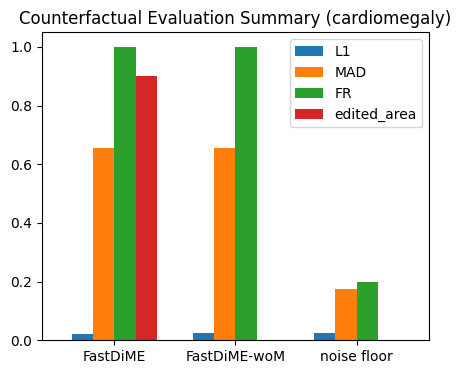

In [ ]:
# Plot the summary results as a bar chart
# Drop "edited_area" from summary 
summary.plot.bar(rot=0, figsize=(5, 4), width=0.7)
plt.title(f"Counterfactual Evaluation Summary ({DISEASE})")
 

### 6.4 Paired comparison: masked vs unmasked

Same image, same noise draw, so the difference is attributable to the mask alone.

In [ ]:
piv  = res.pivot_table(index="img", columns="mode", values="cf_prob")
meta = res.groupby("img")[["cell", "target", "orig_prob"]].first()
piv  = piv.join(meta)
s    = np.where(piv["target"] == 1, 1, -1)

piv["drift"] = s * (piv["noise floor"] - piv["orig_prob"])
for m in ("FastDiME", "FastDiME-woM"):
    piv[f"lift_{m}"] = s * (piv[m] - piv["noise floor"])

print(f"\nfloor L1    : {summary.loc['noise floor', 'L1']:.4f}")
print(f"floor drift : {piv['drift'].mean():+.4f}")
for m in ("FastDiME", "FastDiME-woM"):
    c = piv[f"lift_{m}"]
    print(f"{m:14s} lift: {c.mean():+.4f}   (range {c.min():+.3f} to {c.max():+.3f})")

# paired comparison — same image, same noise draw, so this is the honest test
d = piv["lift_FastDiME"] - piv["lift_FastDiME-woM"]
print(f"\nmasked − unmasked lift: {d.mean():+.4f}  "
      f"(sd {d.std():.4f}, wins {int((d > 0).sum())}/{len(d)})")

print("\nby cell:")
print(piv.groupby("cell")[["drift", "lift_FastDiME", "lift_FastDiME-woM"]]
         .agg(["mean", "count"]).round(3).to_string())


floor L1    : 0.0237
floor drift : +0.1039
FastDiME       lift: +0.5505   (range +0.129 to +0.846)
FastDiME-woM   lift: +0.5520   (range +0.154 to +0.824)

masked − unmasked lift: -0.0015  (sd 0.0261, wins 10/20)

by cell:
      drift       lift_FastDiME       lift_FastDiME-woM      
       mean count          mean count              mean count
cell                                                         
FN   -0.081     5         0.757     5             0.740     5
FP    0.293     5         0.259     5             0.282     5
TN   -0.033     5         0.732     5             0.725     5
TP    0.238     5         0.455     5             0.461     5


## 7. Graded counterfactuals — three intensities per image

Instead of one counterfactual at a fixed τ, take **three snapshots along a single guided
trajectory**: just past the decision boundary, midway, and deep into the opposite class.

**Why not vary τ.** τ controls how much of the original is destroyed before the reverse
process starts, so raising it buys hallucination and drift, not a deeper push into the
target class — that is what the `noise floor` row of §4 measures. "How far into the
opposite class" is a position on the **classifier's probability axis**, and
`p_sample_once` already reports that probability at every step.

So: one trajectory, snapshot `x̄₀` the first time the probability crosses each level. The
three counterfactuals are **nested** — level 1 is a prefix of level 2 is a prefix of
level 3 — so the progression is one edit pushed further, not three unrelated samples. It
also costs a third of three separate runs.

Everything below calls the same functions the batch script does
(`final_experiment/code/cf_generate_levels.py`), so what you see here is what the 5,000-image
run produces.

### 7.1 The levels: three equally spaced probabilities

| level | name | meaning |
|---|---|---|
| 1 | `low` | just inside the class, near its minimum |
| 2 | `mid` | the midpoint — literally halfway between the two extremes |
| 3 | `high` | near the class maximum |

Equally spaced **in probability**, not in rank: the step from `low` to `mid` is the same
size as `mid` to `high`. The levels are a ruler laid across the class.

**Why the endpoints are per-disease.** "Near the maximum" cannot be a constant, because
C0's confidence differs enormously between tasks. Over correctly-classified positives:

| disease | p95 | max |
|---|---|---|
| effusion | 0.978 | 0.999 |
| cardiomegaly | 0.951 | 0.999 |
| atelectasis | 0.603 | 0.889 |
| consolidation | 0.309 | 0.652 |

A fixed high end of 0.95 is near-max for effusion and **unreachable** for consolidation —
C0 essentially never outputs it, so that counterfactual would be asking for something
outside the model's own range. Each disease takes its endpoints from its own distribution.

The resulting levels, with their step size:

| disease | low | mid | high | step |
|---|---|---|---|---|
| cardiomegaly | 0.197 | 0.574 | 0.951 | 0.377 |
| atelectasis | 0.203 | 0.403 | 0.603 | 0.200 |
| effusion | 0.471 | 0.724 | 0.978 | 0.254 |
| edema | 0.326 | 0.614 | 0.903 | 0.288 |
| consolidation | 0.074 | 0.191 | 0.309 | 0.118 |

**Endpoints are p5 and p95**, taken over class members C0 *also classifies correctly*.
The true max is a single outlier image and a poor target; p95 is the edge of the bulk. The
correctness restriction stops an endpoint landing on the wrong side of the decision
boundary, which would make that "counterfactual" not a member of the target class at all.

In [ ]:
import importlib
import cf_generate_levels as cgl
importlib.reload(cgl)

LEVELS = cgl.compute_levels(df, cfg.threshold, disease=DISEASE)

print(f"{DISEASE}   threshold = {cfg.threshold:.4f}")
print(f"endpoints: p{LEVELS['low_pct']:.0f} .. p{LEVELS['high_pct']:.0f} "
      f"of the correctly-classified class\n")
for d, step in (("to_positive", "step_pos"), ("to_negative", "step_neg")):
    vals = "   ".join(f"{n}={v:.4f}" for n, v in zip(cgl.LEVEL_NAMES, LEVELS[d]))
    print(f"  {d:12s} {vals}      step {LEVELS[step]:+.4f}")

print(f"\n  read from  {LEVELS['n_pos_correct']:,} correct positives"
      f" / {LEVELS['n_neg_correct']:,} correct negatives")
print(f"  class range   pos up to {LEVELS['max_pos']:.4f}"
      f"   neg down to {LEVELS['min_neg']:.4f}")

# Both must hold: equal steps, and every level on the correct side of thr.
for d, cmp_ in (("to_positive", lambda v: v > cfg.threshold),
                ("to_negative", lambda v: v < cfg.threshold)):
    lv = LEVELS[d]
    steps = np.diff(lv)
    print(f"  {d:12s} equal steps: {np.allclose(steps, steps[0])}"
          f"   all on correct side: {all(cmp_(v) for v in lv)}")

cardiomegaly   threshold = 0.1598
endpoints: p5 .. p95 of the correctly-classified class

  to_positive  low=0.1974   mid=0.5744   high=0.9514      step +0.3770
  to_negative  low=0.1251   mid=0.0649   high=0.0046      step -0.0602

  read from  8,781 correct positives / 66,178 correct negatives
  class range   pos up to 0.9989   neg down to 0.0004
  to_positive  equal steps: True   all on correct side: True
  to_negative  equal steps: True   all on correct side: True


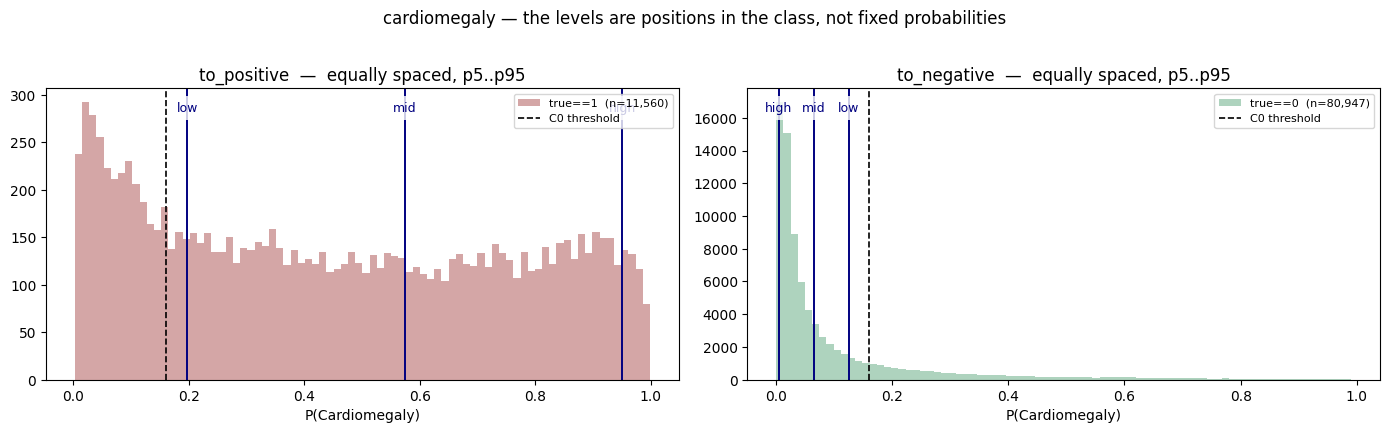

In [ ]:
# Where the levels sit in the real probability distributions.
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))

for j, (side, col, lv_key) in enumerate(
        [(1, "#A03B3B", "to_positive"), (0, "#4C9F70", "to_negative")]):
    p = df.loc[df.true == side, "prob"]
    ax[j].hist(p, bins=80, color=col, alpha=.45,
               label=f"true=={side}  (n={len(p):,})")
    ax[j].axvline(cfg.threshold, ls="--", c="k", lw=1.2, label="C0 threshold")
    for n, v in zip(cgl.LEVEL_NAMES, LEVELS[lv_key]):
        ax[j].axvline(v, ls="-", c="navy", lw=1.4)
        ax[j].annotate(n, (v, ax[j].get_ylim()[1] * .92), fontsize=9,
                       color="navy", ha="center",
                       bbox=dict(fc="white", ec="none", alpha=.8))
    ax[j].set_title(f"{lv_key}  —  equally spaced, "
                    f"p{LEVELS['low_pct']:.0f}..p{LEVELS['high_pct']:.0f}")
    ax[j].set_xlabel(f"P({cfg.target_col})")
    ax[j].legend(fontsize=8)

plt.suptitle(f"{DISEASE} — the levels are positions in the class, not fixed probabilities",
             y=1.02)
plt.tight_layout(); plt.show()

### 7.2 Why full trajectories, and not snapshots

The first design ran **one** trajectory per image and saved `x̄₀` whenever the probability
crossed a level. It was replaced, and the reason is worth recording because it is a real
methodological trap.

**Those snapshots are blurry, by construction.** `x̄₀` is `out['denoised']`, the model's
one-shot estimate of a clean x₀ from the current noisy state — denoised algebraically, but
the authors' own name for it is `x_0_blur`. Estimated from a heavily corrupted x_t at high
t, it is a soft, low-confidence reconstruction. Since the levels stopped at different t,
they were blurred by *different amounts*:

| level | stop t | sharpness vs original |
|---|---|---|
| low | 94 | 84.7% |
| mid | 89 | 85.5% |
| high | 42 | **92.0%** |

Sharpness tracked the stop timestep almost perfectly, so "intensity" was partly a
**sharpness axis** — a downstream CNN could separate the levels on blur alone, without
looking at anatomy.

**Finishing the snapshots to t=1 did not rescue it.** Two tails were tried:

| tail | low | mid | high | outcome |
|---|---|---|---|---|
| target | 0.413 | 0.657 | 0.900 | |
| unguided (`scale=0`) | 0.116 | 0.068 | 0.068 | destroyed — below threshold, all identical |
| guided, aiming past target | 0.493 | 0.728 | 0.860 | levels survive, drift short by up to 0.18 |

With no classifier term the tail is just the diffusion prior finishing the image, and the
prior has no reason to preserve a classifier-driven edit — over ~90 steps it walks back to
the original class. A guided tail only re-pushes *after* the probability has slipped, and
one step cannot undo 68 steps of drift.

**Running each level as its own complete trajectory removes the problem by construction.**
Measured sharpness range 0.6%, against 1.6% and 2.6% for the two snapshot variants — and no
tail to correct, because the classifier term pins the probability at every step rather than
chasing it afterwards. That is what `run_one` does now.

The cost is 3 full trajectories per image instead of 1. Still cheaper than the guided-tail
variant (one trajectory plus three tails), which measured 32.6s against 25.2s.

### 7.3 Choosing τ and scale — where the levels actually land

The soft-target approach is settled (§7.5). What remains is tuning, and the question that
decides it is simple: **do the three levels land where they were aimed, and do they stay
apart?**

`cf_soft_sweep.py` sweeps (τ, scale) over a balanced sample on two tasks with very
different C0 ranges, and reports per cell:

- **`bias_L1/L2/L3`** — mean *signed* error per level, in probability units. A bias of
  −0.027 means that level lands 0.027 below its target. All-negative = still underpushing;
  mixed signs = converged.
- **`spread`** — the gap between the lowest and highest level. **This is the objective**:
  the levels have to be distinct. Landing on exact probabilities matters much less.
- **`l1_total`** — edit size, to catch a setting that buys accuracy by editing more.
- **`sharp_range`** — should stay ~0 in every cell; it is structural to soft targets.

In [ ]:
import glob, os

SWEEP_FILES = sorted(glob.glob("/work3/s251710/thesis_results/CF_levels/soft_sweep*.csv"))
print("sweep files:", [os.path.basename(f) for f in SWEEP_FILES])

sw = pd.concat([pd.read_csv(f) for f in SWEEP_FILES], ignore_index=True)
sw = sw.drop_duplicates(subset=["disease", "tau", "scale"], keep="last")

show = ["disease", "tau", "scale", "mean_err", "bias_L1", "bias_L2", "bias_L3",
        "spread", "l1_total", "sharp_range", "secs"]
print(sw[[c for c in show if c in sw.columns]].round(4).to_string(index=False))

sweep files: ['soft_sweep_stage1.csv']
     disease  tau  scale  mean_err  bias_L1  bias_L2  bias_L3  spread  l1_total  sharp_range    secs
    effusion  150  150.0    0.0647  -0.0565  -0.0510  -0.0428  0.3665    0.0378       0.0028 25.2570
    effusion  150  300.0    0.0427  -0.0351  -0.0392  -0.0266  0.3823    0.0370       0.0080 24.8642
    effusion  150  450.0    0.0350  -0.0297  -0.0363  -0.0156  0.3909    0.0365       0.0339 24.7806
    effusion  150  600.0    0.0285  -0.0264  -0.0274  -0.0115  0.4032    0.0367       0.0888 24.8148
cardiomegaly  150  150.0    0.0337  -0.0002   0.0009  -0.0150  0.4079    0.0325       0.0045 24.8627
cardiomegaly  150  300.0    0.0252   0.0011  -0.0032  -0.0077  0.4210    0.0316       0.0055 24.8890
cardiomegaly  150  450.0    0.0302  -0.0013   0.0103  -0.0077  0.4273    0.0310       0.0213 24.8895
cardiomegaly  150  600.0    0.0212  -0.0035   0.0039  -0.0070  0.4280    0.0305       0.0506 24.8253


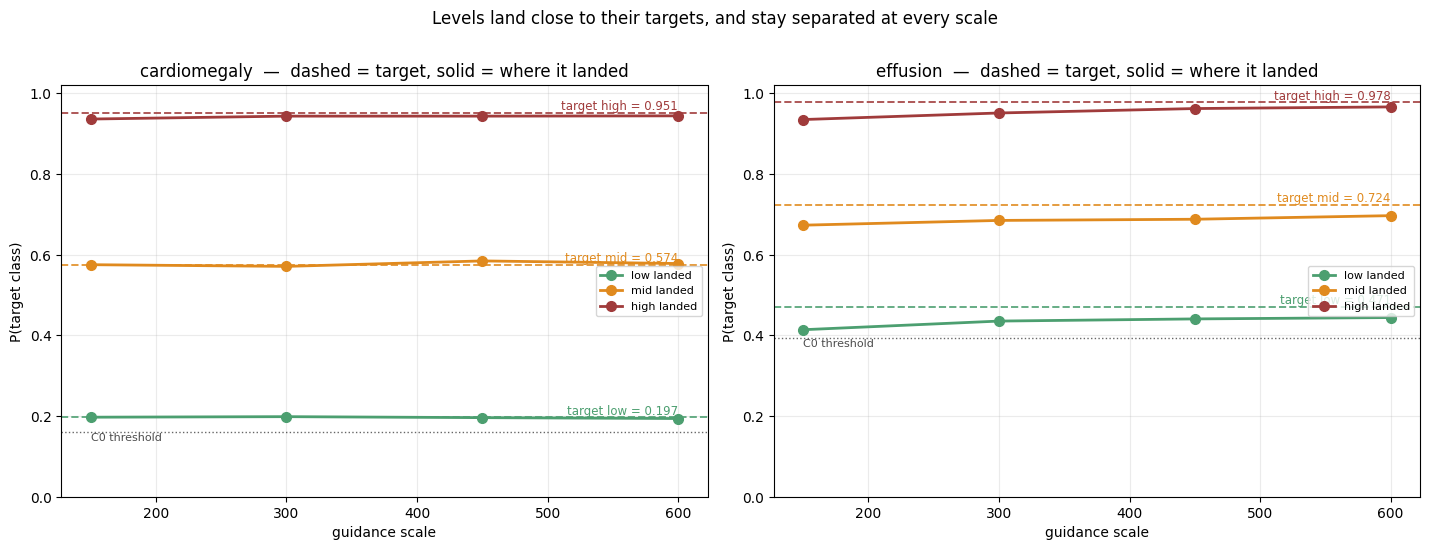

In [ ]:
# Where the levels land, against where they were aimed.
diseases = sorted(sw["disease"].unique())
fig, axes = plt.subplots(1, len(diseases), figsize=(7.2 * len(diseases), 5.4),
                         squeeze=False)
axes = axes[0]

for ax, dis in zip(axes, diseases):
    g = sw[sw["disease"] == dis].sort_values("scale")

    # The targets for this disease, recomputed the same way the sweep did.
    dfd = pd.read_csv(f"/work3/s251710/thesis_results/C2_final/{dis}/c2_data.csv",
                      usecols=["prob", "true", "pred", "correct"])
    thr = float(open("/work3/s251710/thesis_results/C0_final/multilabel_ignore/"
                     f"{dis}/threshold.txt").read().strip())
    lv = cgl.compute_levels(dfd, thr, disease=dis)
    tg = lv["to_positive"]

    cols = ["#4C9F70", "#E08A1E", "#A03B3B"]
    for i, (name, t) in enumerate(zip(cgl.LEVEL_NAMES, tg)):
        # The target: a horizontal line. Where it landed: the line plus the bias.
        ax.axhline(t, color=cols[i], ls="--", lw=1.4, alpha=.85)
        ax.annotate(f"target {name} = {t:.3f}", (g["scale"].max(), t),
                    fontsize=8.5, color=cols[i], va="bottom", ha="right")
        ax.plot(g["scale"], t + g[f"bias_L{i+1}"], "o-", color=cols[i],
                lw=2, ms=7, label=f"{name} landed")

    ax.axhline(thr, color="k", ls=":", lw=1, alpha=.6)
    ax.annotate("C0 threshold", (g["scale"].min(), thr), fontsize=8,
                va="top", ha="left", alpha=.7)
    ax.set_xlabel("guidance scale"); ax.set_ylabel(f"P(target class)")
    ax.set_title(f"{dis}  —  dashed = target, solid = where it landed")
    ax.set_ylim(0, 1.02); ax.grid(alpha=.25); ax.legend(fontsize=8, loc="center right")

plt.suptitle("Levels land close to their targets, and stay separated at every scale",
             y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

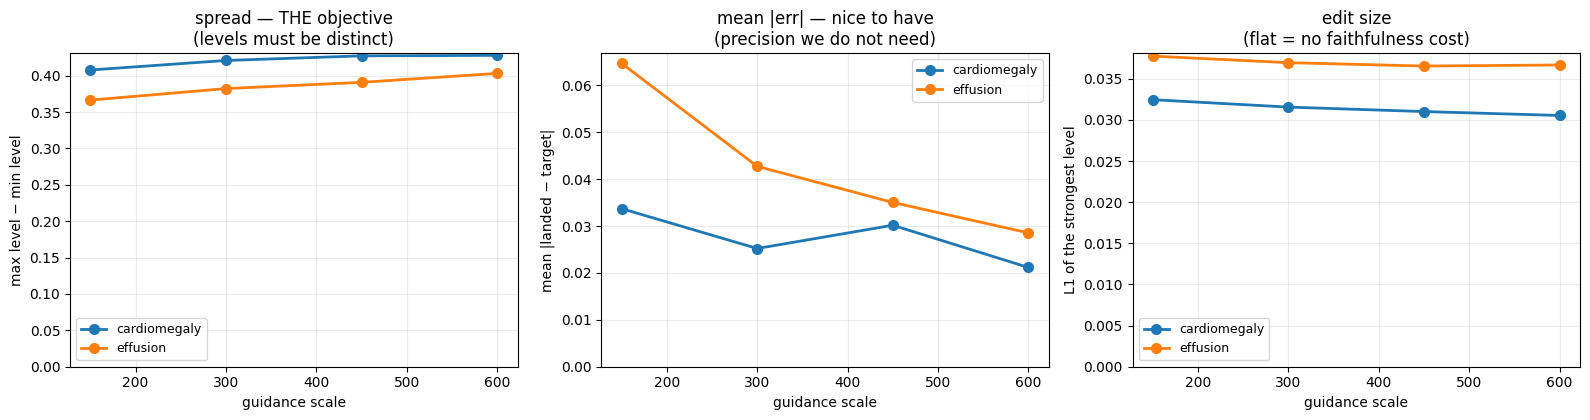

cardiomegaly   scale 150 -> 600:  spread 0.408 -> 0.428  (+5%)   mean_err 0.0337 -> 0.0212
effusion       scale 150 -> 600:  spread 0.366 -> 0.403  (+10%)   mean_err 0.0647 -> 0.0285


In [ ]:
# The two numbers that decide it, and the one that does not.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

for dis in diseases:
    g = sw[sw["disease"] == dis].sort_values("scale")
    axes[0].plot(g["scale"], g["spread"], "o-", lw=2, ms=7, label=dis)
    axes[1].plot(g["scale"], g["mean_err"], "o-", lw=2, ms=7, label=dis)
    axes[2].plot(g["scale"], g["l1_total"], "o-", lw=2, ms=7, label=dis)

axes[0].set_title("spread — THE objective\n(levels must be distinct)")
axes[0].set_ylabel("max level − min level"); axes[0].set_ylim(0, None)
axes[1].set_title("mean |err| — nice to have\n(precision we do not need)")
axes[1].set_ylabel("mean |landed − target|"); axes[1].set_ylim(0, None)
axes[2].set_title("edit size\n(flat = no faithfulness cost)")
axes[2].set_ylabel("L1 of the strongest level"); axes[2].set_ylim(0, None)

for ax in axes:
    ax.set_xlabel("guidance scale"); ax.grid(alpha=.25); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

# Spread barely moves with scale; bias does. That is the argument for the low setting.
for dis in diseases:
    g = sw[sw["disease"] == dis].sort_values("scale")
    lo, hi = g.iloc[0], g.iloc[-1]
    print(f"{dis:14s} scale {lo['scale']:.0f} -> {hi['scale']:.0f}:"
          f"  spread {lo['spread']:.3f} -> {hi['spread']:.3f}"
          f"  ({100*(hi['spread']/lo['spread']-1):+.0f}%)"
          f"   mean_err {lo['mean_err']:.4f} -> {hi['mean_err']:.4f}")

**The decision: τ=150, scale=150.**

- **Spread is flat in scale.** On effusion it moves 0.366 → 0.403 for a 4× stronger
  gradient — 10%. The levels were never clustered; extra scale shifts all three together
  rather than pushing them apart.
- **Cardiomegaly has already converged at 150.** Its bias is −0.000 / +0.001 / −0.015 with
  *mixed signs*, which is residual noise around the optimum, not underpushing.
- **Effusion sits within 0.05**, about 20% of its 0.25 inter-level step. The levels are
  separated by ~0.25 and miss by ~0.03: a 10:1 ratio, so no level can be confused with its
  neighbour and the ordering never breaks.
- **The bias is uniform**, so it preserves spacing — equivalent to having chosen endpoints
  a few hundredths lower. A *non*-uniform bias would distort the equal spacing; this does
  not.
- **No faithfulness cost either way** — `l1_total` is flat across the sweep, so the low
  setting gives up nothing there.

scale=600 would halve effusion's residual bias, but that is precision below what C0 itself
distinguishes: the difference between a 0.967 and a 0.978 effusion is not meaningful to the
classifier. It is 4× the gradient for accuracy we never use.

**On `reach_rate`.** The sweep also reports it, and it is misleading here — it falls as
accuracy improves (cardiomegaly has the best bias of any cell and a reach of 0.08). The
metric is one-sided: it counts landing *at or past* the target, which was the right question
for the stopping-rule design where crossing was the event. For a converged soft target the
estimate lands on both sides about equally, so reach measures how often noise pushes it
over. Read `bias` instead.

### 7.4 The run configuration

Set once, here, from the sweep above. Every counterfactual below this cell — and the batch
script `cf_generate_levels.py` — uses these values, so there is a single place to change
them.

In [ ]:
# Settled by the sweep in §7.3. These match the defaults in
# final_experiment/code/cf_generate_levels.py, so the notebook and the batch
# runs produce the same thing.
TAU   = 150
SCALE = 150
MODE  = "FastDiME-woM"   # unmasked: the mask is FastDiME's shortcut-detection device
# SAMPLER_SEED comes from §3.

print(f"tau={TAU}  scale={SCALE}  mode={MODE}  seed={SAMPLER_SEED}")
print(f"{(TAU - 1) * 3} UNet calls per image  (3 levels x {TAU - 1} steps)")

# Cross-check against the batch script's argparse defaults. If these drift apart
# the notebook stops describing what the 5,000-image runs actually did.
import argparse, inspect, re as _re
_src = inspect.getsource(cgl.main)
_script = {k: float(v) for k, v in
           _re.findall(r'--(tau|scale)"[^)]*?default=(\d+)', _src)}
if _script:
    ok = _script.get("tau") == TAU and _script.get("scale") == SCALE
    print(f"\nscript defaults: tau={_script.get('tau'):.0f} "
          f"scale={_script.get('scale'):.0f}  -> {'match' if ok else 'MISMATCH'}")


tau=150  scale=150  mode=FastDiME-woM  seed=0
447 UNet calls per image  (3 levels x 149 steps)

script defaults: tau=150 scale=150  -> match


### 7.5 One image, three levels

`cgl.run_one` walks the reverse process once and captures `x̄₀` at each crossing — the
identical call the batch script makes per image. A level never reached still returns the
best the trajectory managed, flagged `reached=False`; dropping those would silently
remove the hard images and bias everything downstream.

In [ ]:
# row / x0 / p_orig / pred_orig / direction all come from §3 -- the SAME image
# §3 used. Change it there, not here.
targets = LEVELS[direction]

print(f"{CELL}  {row['path']}")
print(f"p={p_orig:.4f}  pred={pred_orig}  ->  {direction}")
print("targets: " + "  ".join(f"{n}={v:.4f}" for n, v in zip(cgl.LEVEL_NAMES, targets)))

gradcam  = cgl.GradCAM(classifier, cfg.target_idx)
sampler  = cf.make_sampler(MODE, device=cf.DEVICE)

res6 = cgl.run_one(x0, direction, targets, unet, classifier, sampler, gradcam, cfg,
                  tau=TAU, scale=SCALE, seed=SAMPLER_SEED, track_every=1)

print()
for i, name in enumerate(cgl.LEVEL_NAMES):
    ok = "hit " if res6["level_reached"][i] else "MISS"
    print(f"  L{i+1} {name:5s} target={targets[i]:.4f}  got={res6['level_probs'][i]:.4f}"
          f"  [{ok}]"
          f"  L1={np.abs(res6['levels'][i] - res6['x0']).mean():.4f}")

dl1 = [float(np.abs(res6["levels"][i + 1] - res6["levels"][i]).mean()) for i in range(2)]
print(f"\n  dL1 between levels: 1-2={dl1[0]:.4f}  2-3={dl1[1]:.4f}"
      f"   vs total edit {np.abs(res6['levels'][2] - res6['x0']).mean():.4f}")

TN  CheXpert-v1.0-small/train/patient02377/study6/view1_frontal.jpg
p=0.0066  pred=0  ->  to_positive
targets: low=0.1974  mid=0.5744  high=0.9514



  L1 low   target=0.1974  got=0.1811  [MISS]  L1=0.0406
  L2 mid   target=0.5744  got=0.4854  [MISS]  L1=0.0406
  L3 high  target=0.9514  got=0.8306  [MISS]  L1=0.0407

  dL1 between levels: 1-2=0.0018  2-3=0.0024   vs total edit 0.0407


### 7.6 The progression

Top row: the original and the three counterfactuals. Bottom row: what changed at each
level, as `level − original`. The three should get progressively stronger while editing
the *same* region — if `far` edits somewhere else entirely, the guidance has stopped
refining and started wandering.

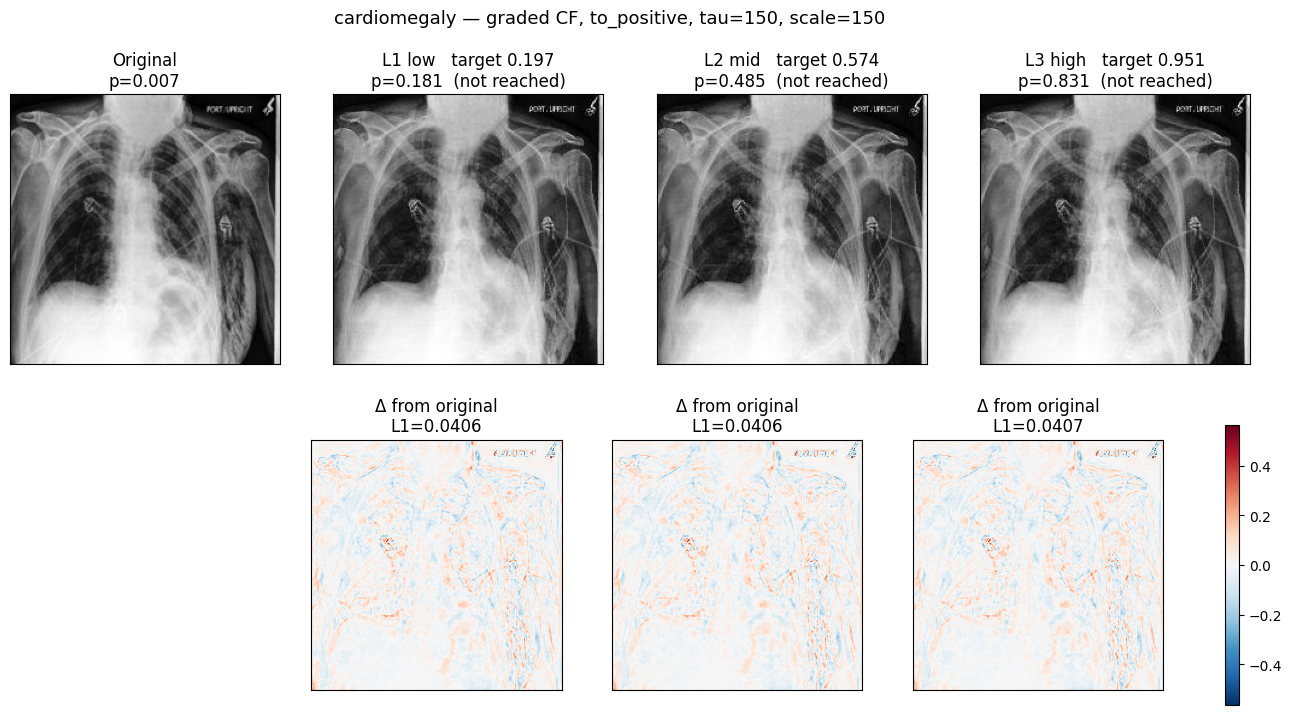

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(res6["x0"], cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title(f"Original\np={p_orig:.3f}")
axes[1, 0].axis("off")

vmax = max(np.abs(res6["levels"][i] - res6["x0"]).max() for i in range(3))
for i, name in enumerate(cgl.LEVEL_NAMES):
    d = res6["levels"][i] - res6["x0"]
    flag = "" if res6["level_reached"][i] else "  (not reached)"
    axes[0, i + 1].imshow(res6["levels"][i], cmap="gray", vmin=0, vmax=1)
    axes[0, i + 1].set_title(f"L{i+1} {name}   target {targets[i]:.3f}\n"
                             f"p={res6['level_probs'][i]:.3f}{flag}")
    im = axes[1, i + 1].imshow(d, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[1, i + 1].set_title(f"Δ from original\nL1={np.abs(d).mean():.4f}")

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[1, :].tolist(), fraction=0.02)
plt.suptitle(f"{DISEASE} — graded CF, {direction}, tau={TAU}, scale={SCALE}",
             y=0.98, fontsize=13)
plt.show()

### 7.7 The trajectory

Probability against timestep, with the three levels marked. This is exactly what the
script stores in `trajectory/<key>.npz` (at `--track-every`, default 5).

Reading it: a curve that shoots past all three in the first few steps means the levels
are too easy for this image — and the `near` CF is not actually near the boundary, it
overshot on the step that crossed. A curve that flattens below `far` is a genuine miss.

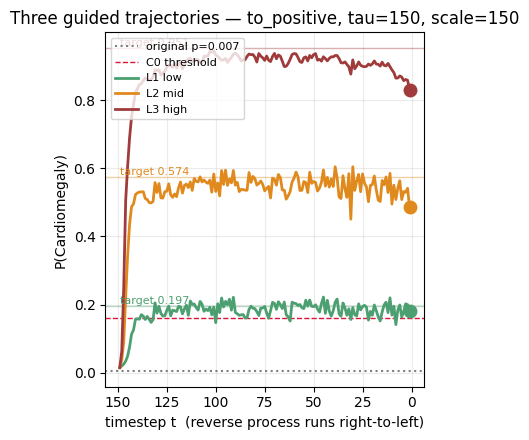

In [ ]:
# One full trajectory PER LEVEL -- res6["trajs"] is a list of three (n_steps,2)
# arrays, all starting from the same noise draw (same seed) and diverging only
# in what probability they were guided towards.
fig, ax = plt.subplots(figsize=(4, 4.5))
ax.axhline(p_orig, ls=":", c="grey", label=f"original p={p_orig:.3f}")
ax.axhline(cfg.threshold, ls="--", c="crimson", lw=1, label="C0 threshold")

cols = ["#4C9F70", "#E08A1E", "#A03B3B"]
for i, (name, v) in enumerate(zip(cgl.LEVEL_NAMES, targets)):
    tj = res6["trajs"][i]
    ax.plot(tj[:, 0], tj[:, 1], lw=2, color=cols[i], label=f"L{i+1} {name}")
    ax.axhline(v, ls="-", c=cols[i], alpha=.4, lw=1)
    ax.annotate(f"target {v:.3f}", (tj[:, 0].max() if len(tj) else TAU, v),
                fontsize=8, color=cols[i], va="bottom", ha="left")
    ax.plot(1, res6["level_probs"][i], "o", ms=9, c=cols[i], zorder=5)

ax.invert_xaxis()            # the reverse process runs t = tau -> 1
ax.set_xlabel("timestep t  (reverse process runs right-to-left)")
ax.set_ylabel(f"P({cfg.target_col})")
ax.set_title(f"Three guided trajectories — {direction}, tau={TAU}, scale={SCALE}")
ax.legend(fontsize=8, loc="best"); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

### 7.8 Saliency at each checkpoint

Grad-CAM on C0's final feature map — the same recipe and the same (7,7) normalised output
as the CAMs already stored in `c2_data.csv`, so these are directly comparable to them.
The script writes one of these per image to `saliency/<key>.npz`, keyed `x0`,
`level_1`, `level_2`, `level_3`.

The question it answers: as the counterfactual gets more extreme, does C0 keep looking at
the same place? A CAM that migrates between levels means the later edits are recruiting
different evidence than the first one did.

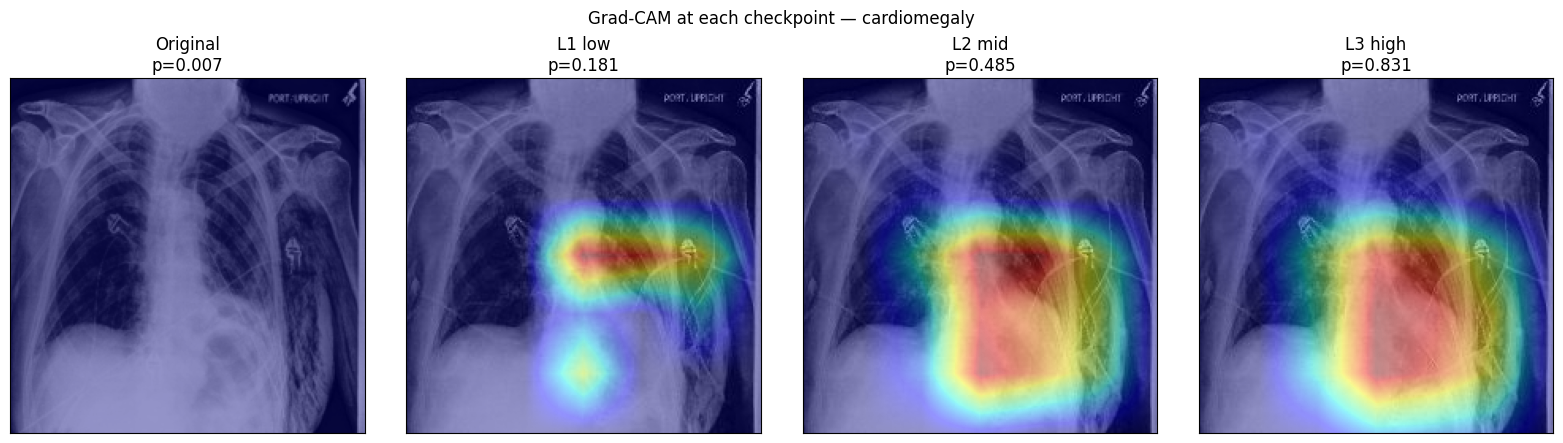

CAM cosine similarity to the original:
  L1 low   0.0000
  L2 mid   0.0000
  L3 high  0.0000


In [ ]:
from scipy.ndimage import zoom

sal_keys   = ["x0"] + [f"level_{i+1}" for i in range(3)]
sal_titles = [f"Original\np={p_orig:.3f}"] + [
    f"L{i+1} {n}\np={res6['level_probs'][i]:.3f}" for i, n in enumerate(cgl.LEVEL_NAMES)]
imgs = [res6["x0"]] + res6["levels"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, k, t, img in zip(axes, sal_keys, sal_titles, imgs):
    cam = zoom(res6["saliency"][k], 224 / 7, order=1)     # (7,7) -> (224,224)
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.imshow(cam, cmap="jet", alpha=0.42, vmin=0, vmax=1)
    ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"Grad-CAM at each checkpoint — {DISEASE}", y=1.02)
plt.tight_layout(); plt.show()

base = res6["saliency"]["x0"].ravel()
print("CAM cosine similarity to the original:")
for i in range(3):
    v = res6["saliency"][f"level_{i+1}"].ravel()
    cos = float(v @ base / (np.linalg.norm(v) * np.linalg.norm(base) + 1e-8))
    print(f"  L{i+1} {cgl.LEVEL_NAMES[i]:5s} {cos:.4f}")

### 7.9 Small batch — do the levels behave?

A handful of images balanced across TP/TN/FP/FN, producing the same columns the script
writes to `manifest.csv`. What to look at:

- **`reach_rate` by level** — if `far` is missed most of the time, raise τ or scale.
- **`mean_L1` by level** — should climb monotonically. It is the cost of the intensity.
- **`mean_stop_t` by level** — how much of the trajectory each level consumed. Levels
  that all stop within a step or two of each other are not three distinct intensities.
- **`dL1` between levels vs total edit** — the real test of distinctness.

In [ ]:
N_PER_CELL = 3
cells_map  = {"TN": (0, 1), "FN": (0, 0), "TP": (1, 1), "FP": (1, 0)}

parts = []
for cell, (p, c) in cells_map.items():
    sel = df[(df["pred"] == p) & (df["correct"] == c)]
    parts.append(sel.sample(min(N_PER_CELL, len(sel)), random_state=1).assign(cell=cell))
sub = pd.concat(parts).reset_index(drop=True)
print(sub["cell"].value_counts().to_string(), "\n")

rows = []
for _, r in tqdm(list(sub.iterrows()), desc="images"):
    xi   = cf.load_image(r["path"])
    p_i  = cf.get_c0_prob(xi, classifier)
    pr_i = cf.predict(p_i, cfg)
    dirn = "to_positive" if pr_i == 0 else "to_negative"
    tg   = LEVELS[dirn]

    out = cgl.run_one(xi, dirn, tg, unet, classifier, sampler, gradcam, cfg,
                      tau=TAU, scale=SCALE, seed=SAMPLER_SEED, track_every=0)

    for i in range(3):
        img = out["levels"][i]
        rows.append({
            "cell": r["cell"], "direction": dirn,
            "level": i + 1, "level_name": cgl.LEVEL_NAMES[i],
            "orig_prob": p_i, "cf_prob": out["level_probs"][i],
            "target_prob": tg[i],
            "reached": int(out["level_reached"][i]),
            "err": out["level_probs"][i] - tg[i],
            "flipped": int(cf.predict(out["level_probs"][i], cfg) != pr_i),
            "l1": float(np.abs(img - out["x0"]).mean()),
            "dl1_prev": (np.nan if i == 0 else
                         float(np.abs(img - out["levels"][i - 1]).mean())),
        })

lev = pd.DataFrame(rows)
print(lev.groupby(["level", "level_name"], sort=True).agg(
    n=("cell", "size"), reach_rate=("reached", "mean"),
    flip_rate=("flipped", "mean"), mean_cf_prob=("cf_prob", "mean"),
    mean_L1=("l1", "mean"), mean_dL1_prev=("dl1_prev", "mean"),
    bias=("err", "mean")).round(4).to_string())

cell
TN    3
FN    3
TP    3
FP    3 



images:   0%|          | 0/12 [00:00<?, ?it/s]

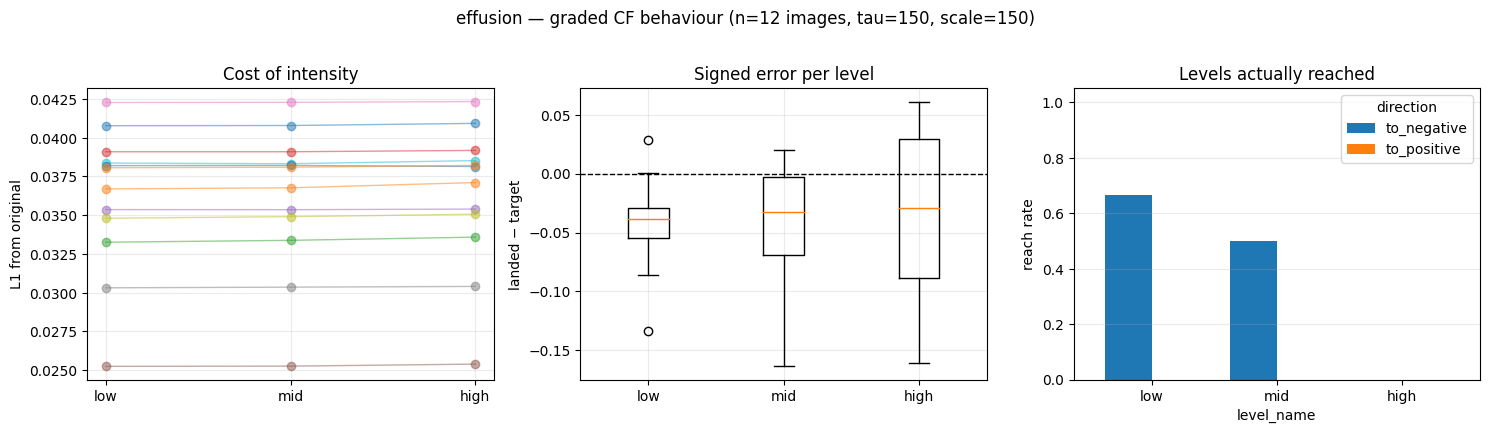

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for _, g in lev.groupby(lev.index // 3):
    axes[0].plot(g["level"], g["l1"], "o-", alpha=.5, lw=1)
axes[0].set_xticks([1, 2, 3]); axes[0].set_xticklabels(cgl.LEVEL_NAMES)
axes[0].set_ylabel("L1 from original"); axes[0].set_title("Cost of intensity")
axes[0].grid(alpha=.25)

axes[1].boxplot([lev.loc[lev.level == i, "err"] for i in (1, 2, 3)],
                labels=cgl.LEVEL_NAMES)
axes[1].axhline(0, ls="--", c="k", lw=1)
axes[1].set_ylabel("landed − target"); axes[1].set_title("Signed error per level")
axes[1].grid(alpha=.25)

rr = lev.pivot_table(index="level_name", columns="direction", values="reached",
                     aggfunc="mean").reindex(cgl.LEVEL_NAMES)
rr.plot.bar(ax=axes[2], rot=0, width=.75)
axes[2].set_ylim(0, 1.05); axes[2].set_ylabel("reach rate")
axes[2].set_title("Levels actually reached"); axes[2].grid(alpha=.25, axis="y")

plt.suptitle(f"{DISEASE} — graded CF behaviour (n={lev.level.eq(1).sum()} images, "
             f"tau={TAU}, scale={SCALE})", y=1.02)
plt.tight_layout(); plt.show()

---

# 7.10 RESULTS OF FULL RUN

`final_experiment/code/cf_generate_levels.py` does per image exactly what 6.3–6.6 do, and
writes:

```
$THESIS_RESULTS/CF_levels/<disease>/
    manifest.csv          one row per (image, level)
    levels.json           the targets + how they were derived
    cf/<key>.npz          x0, cf_level_1..3, level_probs, level_reached,
                          targets, orig_prob, direction
                          (+ unguided, edit_level_1..3 with --unguided)
    saliency/<key>.npz    Grad-CAM at x0 and each of the three levels
    trajectory/<key>.npz  per-step (t, prob), one array per level
```

`<key>` is the image path with `/` → `_`, matching the `cam_path` convention in
`c0_final_predictions.py`.

```bash
# smoke first — 4 images, verbose per-image detail
python final_experiment/code/cf_generate_levels.py \
    --disease cardiomegaly --n 4 --smoke --tau 100 --scale 50

# the real runs (5,000 images each, ~8.6 GPU-h on A100)
bsub < final_experiment/jobs/cf_levels_cardiomegaly.sh
bsub < final_experiment/jobs/cf_levels_atelectasis.sh
```

The jobs resume from `manifest.csv`, so an interrupted run picks up where it stopped and
re-running with a larger `--n` only computes the new images.

**Cost.** τ−1 = 99 UNet calls per image guided-only; `--unguided` doubles it.

In [ ]:
DISEASE = "atelectasis"

In [ ]:
# 1. Load and concatenate shards
total_manifest = []
for shard in range(1, 4):
    man_path = os.path.join(RUN_DIR, f"manifest_shard{shard}of4.csv")
    total_manifest.append(pd.read_csv(man_path))
man = pd.concat(total_manifest, ignore_index=True)

In [ ]:
man

,path,key,cell,true,orig_prob,orig_pred,direction,level,level_name,target_prob,cf_prob,err,reached,flipped,l1
0,CheXpert-v1.0-small/train/patient27519/study2/...,CheXpert-v1.0-small_train_patient27519_study2_...,TN,0,0.007880,0,to_positive,1,low,0.202897,0.152767,-0.050130,0,0,0.035390
1,CheXpert-v1.0-small/train/patient27519/study2/...,CheXpert-v1.0-small_train_patient27519_study2_...,TN,0,0.007880,0,to_positive,2,mid,0.402988,0.340141,-0.062847,0,1,0.035420
2,CheXpert-v1.0-small/train/patient27519/study2/...,CheXpert-v1.0-small_train_patient27519_study2_...,TN,0,0.007880,0,to_positive,3,high,0.603078,0.516864,-0.086214,0,1,0.035447
3,CheXpert-v1.0-small/train/patient34487/study10...,CheXpert-v1.0-small_train_patient34487_study10...,TN,0,0.024293,0,to_positive,1,low,0.202897,0.141635,-0.061262,0,0,0.030666
4,CheXpert-v1.0-small/train/patient34487/study10...,CheXpert-v1.0-small_train_patient34487_study10...,TN,0,0.024293,0,to_positive,2,mid,0.402988,0.341679,-0.061308,0,1,0.030767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16570,CheXpert-v1.0-small/train/patient15635/study8/...,CheXpert-v1.0-small_train_patient15635_study8_...,TN,0,0.036068,0,to_positive,2,mid,0.402988,0.257909,-0.145079,0,1,0.033421
16571,CheXpert-v1.0-small/train/patient15635/study8/...,CheXpert-v1.0-small_train_patient15635_study8_...,TN,0,0.036068,0,to_positive,3,high,0.603078,0.458029,-0.145049,0,1,0.033470
16572,CheXpert-v1.0-small/train/patient02082/study3/...,CheXpert-v1.0-small_train_patient02082_study3_...,TN,0,0.017661,0,to_positive,1,low,0.202897,0.161525,-0.041373,0,0,0.026516
16573,CheXpert-v1.0-small/train/patient02082/study3/...,CheXpert-v1.0-small_train_patient02082_study3_...,TN,0,0.017661,0,to_positive,2,mid,0.402988,0.311643,-0.091345,0,1,0.026550


In [ ]:
# 2. Pre-calculate aggregates grouped by direction and level
summary = (
    man.groupby(["direction", "level", "level_name"])
    .agg(
        flip_rate=("flipped", "mean"),
        mean_cf_prob=("cf_prob", "mean"),
        mean_l1=("l1", "mean"),
        bias=("err", "mean"),
    )
    .reset_index()
)

In [ ]:
summary

,direction,level,level_name,flip_rate,mean_cf_prob,mean_l1,bias
0,to_negative,1,low,0.741091,0.169235,0.032954,-0.009416
1,to_negative,2,mid,0.988727,0.115917,0.032993,0.017549
2,to_negative,3,high,0.999636,0.066585,0.033065,0.048501
3,to_positive,1,low,0.124324,0.152393,0.034965,-0.050505
4,to_positive,2,mid,0.997838,0.306172,0.035002,-0.096816
5,to_positive,3,high,1.000000,0.474097,0.035064,-0.128981


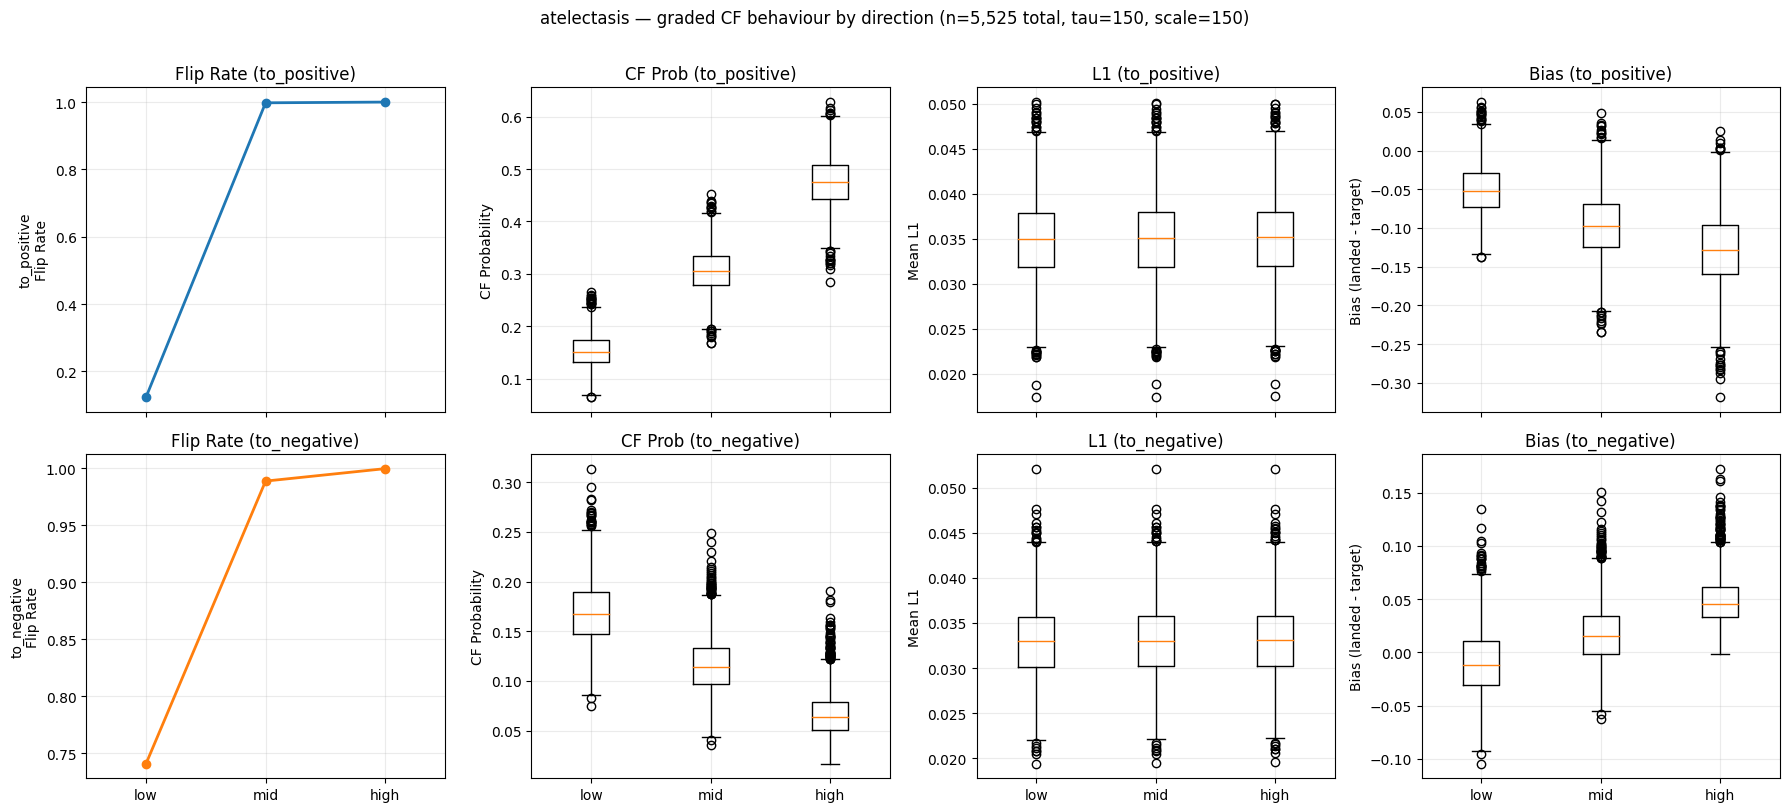

In [ ]:
# 3. Plot a 2x4 grid: row 0 for to_positive, row 1 for to_negative
directions = ["to_positive", "to_negative"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)

for row_idx, direction in enumerate(directions):
    dir_summary = summary[summary.direction == direction]
    dir_man = man[man.direction == direction]

    # Subplot 0: Flip Rate trend
    axes[row_idx, 0].plot(
        dir_summary["level"],
        dir_summary["flip_rate"],
        "o-",
        lw=2,
        color="tab:blue" if direction == "to_positive" else "tab:orange",
    )
    axes[row_idx, 0].set_ylabel(f"{direction}\nFlip Rate")
    axes[row_idx, 0].set_title(f"Flip Rate ({direction})")
    axes[row_idx, 0].grid(alpha=0.25)

    # Subplot 1: CF Probability distribution
    axes[row_idx, 1].boxplot(
        [dir_man.loc[dir_man.level == i, "cf_prob"].dropna() for i in (1, 2, 3)],
        labels=cgl.LEVEL_NAMES,
    )
    axes[row_idx, 1].set_ylabel("CF Probability")
    axes[row_idx, 1].set_title(f"CF Prob ({direction})")
    axes[row_idx, 1].grid(alpha=0.25)

    # Subplot 2: L1 distance distribution
    axes[row_idx, 2].boxplot(
        [dir_man.loc[dir_man.level == i, "l1"].dropna() for i in (1, 2, 3)],
        labels=cgl.LEVEL_NAMES,
    )
    axes[row_idx, 2].set_ylabel("Mean L1")
    axes[row_idx, 2].set_title(f"L1 ({direction})")
    axes[row_idx, 2].grid(alpha=0.25)

    # Subplot 3: Bias distribution
    axes[row_idx, 3].boxplot(
        [dir_man.loc[dir_man.level == i, "err"].dropna() for i in (1, 2, 3)],
        labels=cgl.LEVEL_NAMES,
    )
    axes[row_idx, 3].set_ylabel("Bias (landed - target)")
    axes[row_idx, 3].set_title(f"Bias ({direction})")
    axes[row_idx, 3].grid(alpha=0.25)

for ax in axes[1]:
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(cgl.LEVEL_NAMES)

plt.suptitle(
    f"{DISEASE} — graded CF behaviour by direction (n={len(man)//3:,} total, tau={TAU}, scale={SCALE})",
    y=1.01,
)
plt.tight_layout()
plt.show()

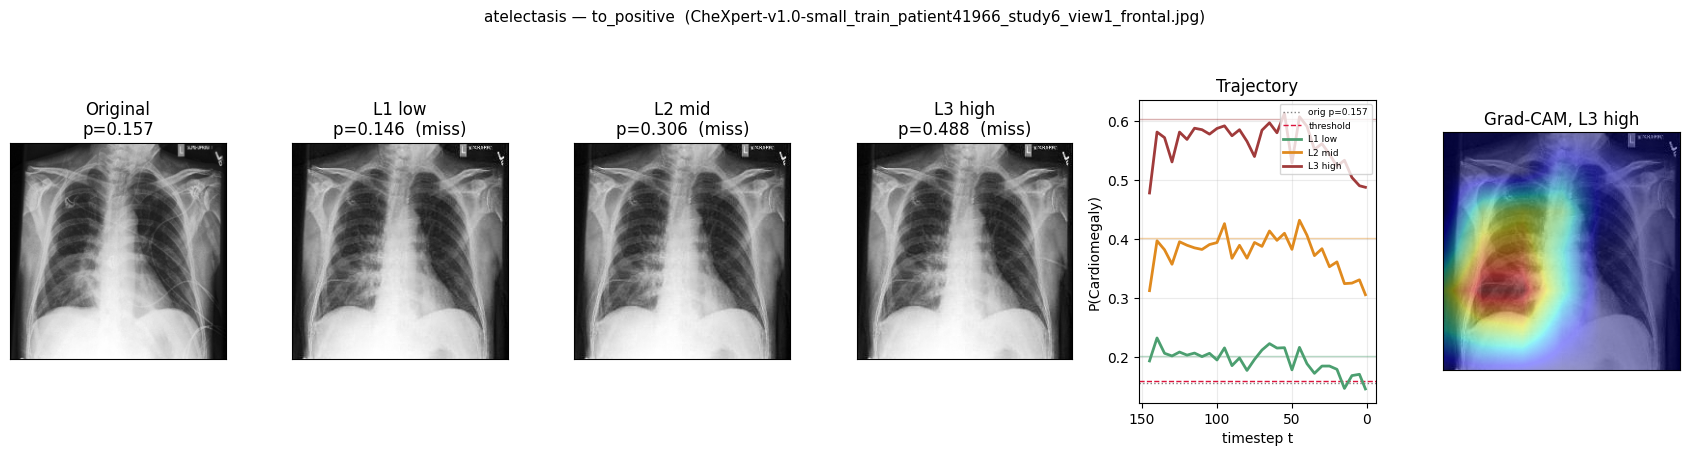

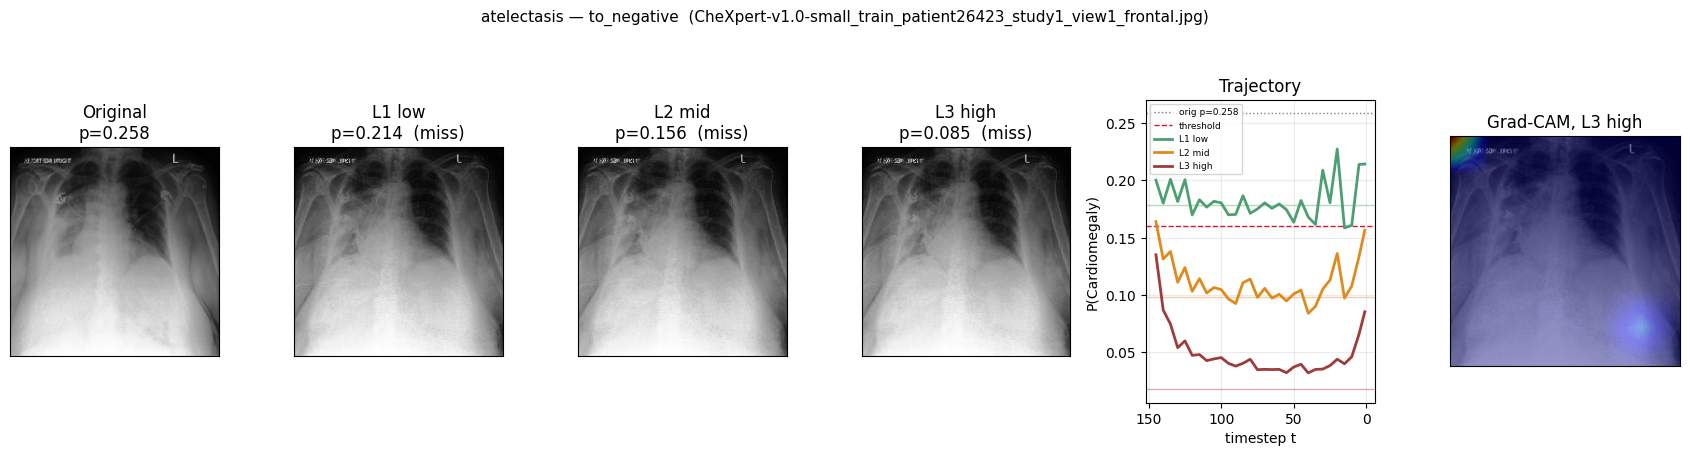

In [ ]:
# %% [markdown]
# ### 7.11 A few examples, from disk
# 
# Not a re-run — these load the saved artifacts from the full run (`cf/`, `saliency/`,
# `trajectory/`) keyed by `man["key"]`, the same files `cf_generate_levels.py` wrote.
# Three `to_positive` and three `to_negative` images, each with its three CF levels, its
# guided trajectory (from `trajectory/<key>.npz`), and its Grad-CAM progression (from
# `saliency/<key>.npz`) — the same plots as §7.6–§7.8, but reconstructed from stored
# results rather than a live `cgl.run_one` call.

# %%
from scipy.ndimage import zoom

PICK = 0   
N_EXAMPLES = 1
LEVEL_NAMES = cgl.LEVEL_NAMES
COLS = ["#4C9F70", "#E08A1E", "#A03B3B"]

# one row per image (level==1 dedups the manifest, which has one row per (image, level))
keys_by_dir = {
    d: (man[(man.direction == d) & (man.level == 1)]
        .sample(min(N_EXAMPLES, (man.direction == d).sum() // 3), random_state=PICK)
        ["key"].tolist())
    for d in ("to_positive", "to_negative")
}

def load_example(key):
    cf_d   = np.load(os.path.join(RUN_DIR, "cf", f"{key}.npz"))
    sal_d  = np.load(os.path.join(RUN_DIR, "saliency", f"{key}.npz"))
    traj_d = np.load(os.path.join(RUN_DIR, "trajectory", f"{key}.npz"))
    return cf_d, sal_d, traj_d

for direction, keys in keys_by_dir.items():
    for key in keys:
        cf_d, sal_d, traj_d = load_example(key)

        x0_img      = cf_d["x0"]
        levels_img  = [cf_d[f"cf_level_{i+1}"] for i in range(3)]
        level_probs = cf_d["level_probs"]
        level_ok    = cf_d["level_reached"]
        targets     = cf_d["targets"]
        orig_prob   = float(cf_d["orig_prob"])

        fig = plt.figure(figsize=(17, 4.3))
        gs  = fig.add_gridspec(1, 6, width_ratios=[1, 1, 1, 1, 1.1, 1.1])

        # -- levels row: original + 3 CFs --
        ax0 = fig.add_subplot(gs[0, 0])
        ax0.imshow(x0_img, cmap="gray", vmin=0, vmax=1)
        ax0.set_title(f"Original\np={orig_prob:.3f}")
        ax0.set_xticks([]); ax0.set_yticks([])

        for i, name in enumerate(LEVEL_NAMES):
            ax = fig.add_subplot(gs[0, i + 1])
            ax.imshow(levels_img[i], cmap="gray", vmin=0, vmax=1)
            flag = "" if level_ok[i] else "  (miss)"
            ax.set_title(f"L{i+1} {name}\np={level_probs[i]:.3f}{flag}")
            ax.set_xticks([]); ax.set_yticks([])

        # -- trajectory --
        axt = fig.add_subplot(gs[0, 4])
        axt.axhline(orig_prob, ls=":", c="grey", lw=1, label=f"orig p={orig_prob:.3f}")
        axt.axhline(cfg.threshold, ls="--", c="crimson", lw=1, label="threshold")
        for i, name in enumerate(LEVEL_NAMES):
            tj = traj_d[f"level_{i+1}"] if f"level_{i+1}" in traj_d.files else traj_d[str(i)]
            axt.plot(tj[:, 0], tj[:, 1], lw=2, color=COLS[i], label=f"L{i+1} {name}")
            axt.axhline(targets[i], ls="-", c=COLS[i], alpha=.4, lw=1)
        axt.invert_xaxis()
        axt.set_xlabel("timestep t"); axt.set_ylabel(f"P({cfg.target_col})")
        axt.set_title("Trajectory"); axt.legend(fontsize=6.5, loc="best")
        axt.grid(alpha=.25)

        # -- saliency: original + high level overlay --
        axs = fig.add_subplot(gs[0, 5])
        cam = zoom(sal_d["level_3"], 224 / sal_d["level_3"].shape[0], order=1)
        axs.imshow(levels_img[2], cmap="gray", vmin=0, vmax=1)
        axs.imshow(cam, cmap="jet", alpha=0.42, vmin=0, vmax=1)
        axs.set_title(f"Grad-CAM, L3 {LEVEL_NAMES[2]}")
        axs.set_xticks([]); axs.set_yticks([])

        plt.suptitle(f"{DISEASE} — {direction}  ({key})", y=1.05, fontsize=11)
        plt.tight_layout(); plt.show()

TP: n=799
TN: n=2508
FP: n=1952
FN: n=266


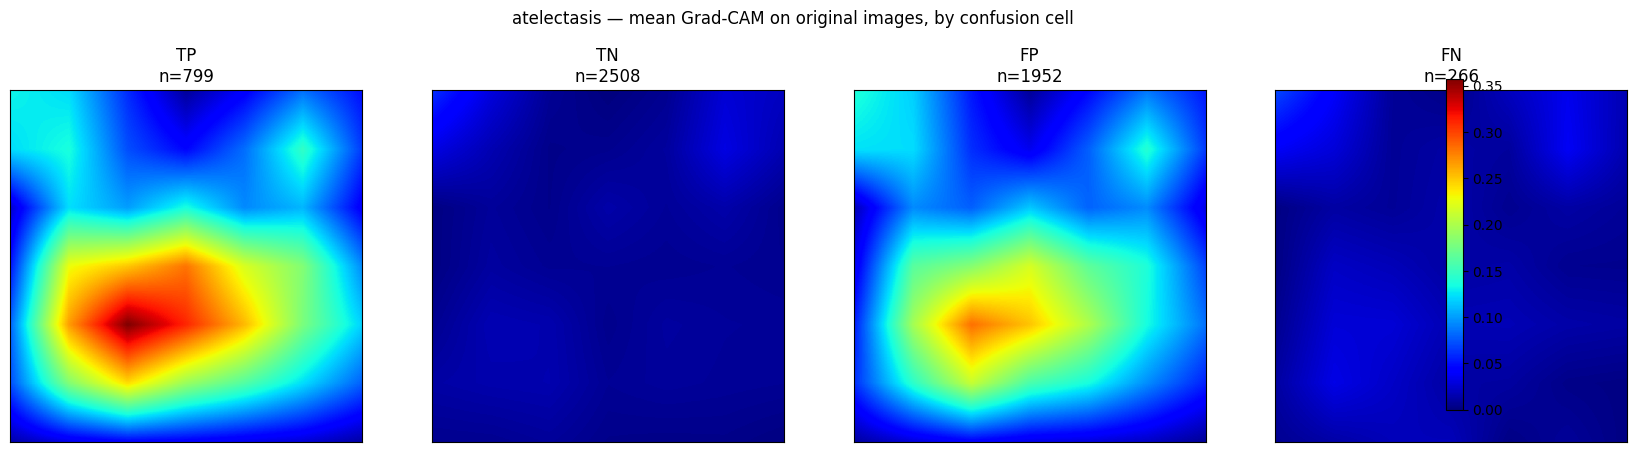

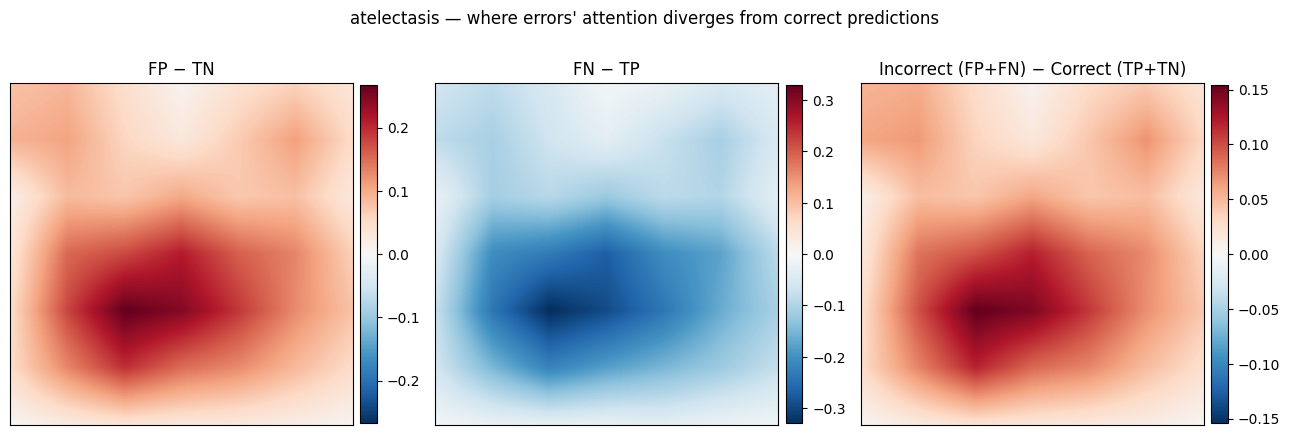

cosine similarity between cell-average CAMs:
  TP vs TN: 0.6681
  TP vs FP: 0.9956
  TP vs FN: 0.7535
  TN vs FP: 0.7204
  TN vs FN: 0.9586
  FP vs FN: 0.7966


In [ ]:
# %% [markdown]
# ### 7.12 Average saliency by confusion cell
# 
# Grad-CAM on the *original* image (`sal_d["x0"]`), averaged separately within each of
# TP / TN / FP / FN. Same cells as §3/§6. If a wrong-prediction group's attention sits
# somewhere systematically different from its correct counterpart — off the anatomy, or on
# a different region — this is where it shows.

# %%
CELLS = ["TP", "TN", "FP", "FN"]

one_per_image = man[man.level == 1].drop_duplicates(subset="key")   # one row per image
keys_by_cell = {c: one_per_image.loc[one_per_image.cell == c, "key"].tolist() for c in CELLS}

def average_saliency(keys, run_dir):
    """Mean Grad-CAM (on x0) over a list of manifest keys. Skips files that fail to load."""
    acc, n, missing = None, 0, 0
    for key in keys:
        try:
            sal_d = np.load(os.path.join(run_dir, "saliency", f"{key}.npz"))
        except FileNotFoundError:
            missing += 1
            continue
        cam = sal_d["x0"]
        acc = cam.astype(np.float64) if acc is None else acc + cam
        n += 1
    if missing:
        print(f"  [warn] {missing}/{len(keys)} saliency files missing")
    return (acc / n if n else None), n

sal_by_cell, n_by_cell = {}, {}
for c in CELLS:
    sal_by_cell[c], n_by_cell[c] = average_saliency(keys_by_cell[c], RUN_DIR)
    print(f"{c}: n={n_by_cell[c]}")

# %%
from scipy.ndimage import zoom

vmax = max(s.max() for s in sal_by_cell.values() if s is not None)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.3))
for ax, c in zip(axes, CELLS):
    cam = sal_by_cell[c]
    if cam is None:
        ax.axis("off"); ax.set_title(f"{c}\n(no data)"); continue
    cam_up = zoom(cam, 224 / cam.shape[0], order=1)
    im = ax.imshow(cam_up, cmap="jet", vmin=0, vmax=vmax)
    ax.set_title(f"{c}\nn={n_by_cell[c]}")
    ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.02)
plt.suptitle(f"{DISEASE} — mean Grad-CAM on original images, by confusion cell", y=1.04)
plt.tight_layout(); plt.show()

# %%
# Contrasts: correct vs incorrect within each predicted class, and pooled.
def diff_panel(ax, a, b, label_a, label_b, run_dir=RUN_DIR):
    d = zoom(a - b, 224 / a.shape[0], order=1)
    dv = np.abs(d).max()
    im = ax.imshow(d, cmap="RdBu_r", vmin=-dv, vmax=dv)
    ax.set_title(f"{label_a} − {label_b}")
    ax.set_xticks([]); ax.set_yticks([])
    return im

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
diff_panel(axes[0], sal_by_cell["FP"], sal_by_cell["TN"], "FP", "TN")   # pred=1 errors
diff_panel(axes[1], sal_by_cell["FN"], sal_by_cell["TP"], "FN", "TP")   # pred=0 errors
sal_correct   = (sal_by_cell["TP"] * n_by_cell["TP"] + sal_by_cell["TN"] * n_by_cell["TN"]) / (n_by_cell["TP"] + n_by_cell["TN"])
sal_incorrect = (sal_by_cell["FP"] * n_by_cell["FP"] + sal_by_cell["FN"] * n_by_cell["FN"]) / (n_by_cell["FP"] + n_by_cell["FN"])
im = diff_panel(axes[2], sal_incorrect, sal_correct, "Incorrect (FP+FN)", "Correct (TP+TN)")
for ax in axes:
    fig.colorbar(axes[0].images[0] if ax is axes[0] else ax.images[0], ax=ax, fraction=0.046, pad=0.02)
plt.suptitle(f"{DISEASE} — where errors' attention diverges from correct predictions", y=1.03)
plt.tight_layout(); plt.show()

print("cosine similarity between cell-average CAMs:")
cells_present = [c for c in CELLS if sal_by_cell[c] is not None]
for i, c1 in enumerate(cells_present):
    for c2 in cells_present[i+1:]:
        v1, v2 = sal_by_cell[c1].ravel(), sal_by_cell[c2].ravel()
        cos = float(v1 @ v2 / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8))
        print(f"  {c1} vs {c2}: {cos:.4f}")